The problem is that I should use proper barcode counting, I must see how many of barcodes I am counting from barcode sequencing
Some of those barcodes have N in their sequence and with simple matching you can't use them, there should be proper way to assign them, like minimap2

In [62]:
import itertools
import os
import re
import warnings
from scipy import stats


import sfmap_normal
from scipy.stats import pearsonr, mannwhitneyu, wilcoxon, gaussian_kde, ttest_ind

import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 300  # High resolution
import numpy as np

from datetime import datetime
from collections import Counter

from matplotlib_venn import venn3, venn3_circles


import alignparse.targets
import seaborn as sns
from IPython.display import display, HTML
from matplotlib.backends.backend_pdf import PdfPages


from sklearn.decomposition import PCA
from adjustText import adjust_text

import pandas as pd
from pathlib import Path
from sklearn.metrics import r2_score

from Bio.Seq import Seq
from Bio import SeqIO

import random

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Helvetica'

# Set global font to Helvetica
mpl.rcParams['font.family'] = 'Helvetica'


import yaml
warnings.simplefilter('ignore')

In [63]:
def three_to_one_mut(mutation):
    aa_table = {
        'Ala':'A','Arg':'R','Asn':'N','Asp':'D','Cys':'C',
        'Gln':'Q','Glu':'E','Gly':'G','His':'H','Ile':'I',
        'Leu':'L','Lys':'K','Met':'M','Phe':'F','Pro':'P',
        'Ser':'S','Thr':'T','Trp':'W','Tyr':'Y','Val':'V',
        'Ter':'*'
    }

    import re

    # Remove white space if present
    mutation = mutation.strip()
    # Remove leading "p." if present
    mutation = mutation.lstrip('p.')
    match = re.match(r"([A-Za-z]{3})(\d+)([A-Za-z]{3})", mutation)
    if not match:
        return mutation  # return unchanged if format unknown

    ref, pos, alt = match.groups()
    return aa_table.get(ref, ref) + pos + aa_table.get(alt, alt)


def one_to_three_mut(mutation):
    aa_table_reverse = {
        'A': 'Ala', 'R': 'Arg', 'N': 'Asn', 'D': 'Asp', 'C': 'Cys',
        'Q': 'Gln', 'E': 'Glu', 'G': 'Gly', 'H': 'His', 'I': 'Ile',
        'L': 'Leu', 'K': 'Lys', 'M': 'Met', 'F': 'Phe', 'P': 'Pro',
        'S': 'Ser', 'T': 'Thr', 'W': 'Trp', 'Y': 'Tyr', 'V': 'Val',
        '*': 'Ter'
    }

    import re
    
    # Remove white space if present
    mutation = mutation.strip()
    # Remove leading "p." if present (we'll add it back at the end)
    mutation = mutation.lstrip('p.')
    
    # Match patterns like: A123G (standard) or A123* (with Ter)
    match = re.match(r"([A-Za-z\*])(\d+)([A-Za-z\*])", mutation)
    if not match:
        return mutation  # return unchanged if format unknown
    
    ref, pos, alt = match.groups()
    
    # Convert to uppercase for lookup
    ref_upper = ref.upper()
    alt_upper = alt.upper()
    
    # Convert using the reverse table
    ref_three = aa_table_reverse.get(ref_upper, ref)
    alt_three = aa_table_reverse.get(alt_upper, alt)
    
    # Return with "p." prefix
    return f"p.{ref_three}{pos}{alt_three}"

In [64]:
plot_cmap = {
    
    "EmberRed": "#7C1900",
    "TranqMist": "#466058",
    "SapphBlue": "#438CBD",
    "GoldHarmon": "#DACF6D",
    "AmberBurst": "#9E5817",
    "AzureDream": "#61BDD2",
    "CopperSet": "#B99131",
    "TwilightIndigo": "#305CAB",
    "green": "#278343",
    "grey" : "#b7b7b7"
}

Read the configuration file:

In [65]:
with open('config.yaml') as f:
    config = yaml.safe_load(f)

Make output directory for counts:

## Load Codon-Variant table

In [66]:
#read codon_variant_table generated by pacbio sequencing and pbData_analysis
variants = pd.read_table(f'{config["codon_variant_table_file"]}', na_filter=None, sep=',')
        
display(HTML(variants.head().to_html(index=False)))

library,barcode,variant_call_support,number_of_indels,codon_substitutions,aa_substitutions,n_codon_substitutions,n_aa_substitutions,variant_class,aa_substitutions_c
GBA1,AAGCGGACTGCACGTCGTCTTTTTTTTTTT,1,0,,,0,0,wildtype,wildtype
GBA1,ACCATGTATCGACCCTATCATTTTTTTTTT,1,0,CGC78CAG,R78Q,1,1,1 nonsynonymous,R78Q
GBA1,TAAGTCGCTGCGCGGATGTCGTTTTTTTTT,13,0,,,0,0,wildtype,wildtype
GBA1,AGGCAAAACTGCTACTTGCCTGTTTTTTTT,8,0,AGC47TGG,S47W,1,1,1 nonsynonymous,S47W
GBA1,TTGTTTAGCTGTCAACCCCCCGTTTTTTTT,44,0,,,0,0,wildtype,wildtype


In [67]:
#The first part of the code filters invalid codon substitutions like CAA440AAG
#position 440 is CAG not CAA
df=variants.copy()
# --------------------------------------------------
# 1. Build reference codons from CDS sequence
# --------------------------------------------------

cds_seq = (
    "ATGGAGTTTTCAAGTCCTTCCAGAGAGGAATGTCCCAAGCCTTTGAGTAGGGTAAGCATCATGGCTGGCAGCCTCACAGGATTGCTTCTACTTCAGGCAGTGTCGTGGGCATCAGGTGCCCGCCCCTGCATCCCTAAAAGCTTCGGCTACAGCTCGGTGGTGTGTGTCTGCAATGCCACATACTGTGACTCCTTTGACCCCCCGACCTTTCCTGCCCTTGGTACCTTCAGCCGCTATGAGAGTACACGCAGTGGGCGACGGATGGAGCTGAGTATGGGGCCCATCCAGGCTAATCACACGGGCACAGGCCTGCTACTGACCCTGCAGCCAGAACAGAAGTTCCAGAAAGTGAAGGGATTTGGAGGGGCCATGACAGATGCTGCTGCTCTCAACATCCTTGCCCTGTCACCCCCTGCCCAAAATTTGCTACTTAAATCGTACTTCTCTGAAGAAGGAATCGGATATAACATCATCCGGGTACCCATGGCCAGCTGTGACTTCTCCATCCGCACCTACACCTATGCAGACACCCCTGATGATTTCCAGTTGCACAACTTCAGCCTCCCAGAGGAAGATACCAAGCTCAAGATACCCCTGATTCACCGAGCCCTGCAGTTGGCCCAGCGTCCCGTTTCACTCCTTGCCAGCCCCTGGACATCACCCACTTGGCTCAAGACCAATGGAGCGGTGAATGGGAAGGGGTCACTCAAGGGACAGCCCGGAGACATCTACCACCAGACCTGGGCCAGATACTTTGTGAAGTTCCTGGATGCCTATGCTGAGCACAAGTTACAGTTCTGGGCAGTGACAGCTGAAAATGAGCCTTCTGCTGGGCTGTTGAGTGGATACCCCTTCCAGTGCCTGGGCTTCACCCCTGAACATCAGCGAGACTTCATTGCCCGTGACCTAGGTCCTACCCTCGCCAACAGTACTCACCACAATGTCCGCCTACTCATGCTGGATGACCAACGCTTGCTGCTGCCCCACTGGGCAAAGGTGGTACTGACAGACCCAGAAGCAGCTAAATATGTTCATGGCATTGCTGTACATTGGTACCTGGACTTTCTGGCTCCAGCCAAAGCCACCCTAGGGGAGACACACCGCCTGTTCCCCAACACCATGCTCTTTGCCTCAGAGGCCTGTGTGGGCTCCAAGTTCTGGGAGCAGAGTGTGCGGCTAGGCTCCTGGGATCGAGGGATGCAGTACAGCCACAGCATCATCACGAACCTCCTGTACCATGTGGTCGGCTGGACCGACTGGAACCTTGCCCTGAACCCCGAAGGAGGACCCAATTGGGTGCGTAACTTTGTCGACAGTCCCATCATTGTAGACATCACCAAGGACACGTTTTACAAACAGCCCATGTTCTACCACCTTGGCCACTTCAGCAAGTTCATTCCTGAGGGCTCCCAGAGAGTGGGGCTGGTTGCCAGTCAGAAGAACGACCTGGACGCAGTGGCACTGATGCATCCCGATGGCTCTGCTGTTGTGGTCGTGCTAAACCGCTCCTCTAAGGATGTGCCTCTTACCATCAAGGATCCTGCTGTGGGCTTCCTGGAGACAATCTCACCTGGCTACTCCATTCACACCTACCTGTGGCGTCGCCAGTGA"
).upper()

# Map codon position (1-based) -> reference codon
ref_codons = {
    i + 1: cds_seq[i*3:(i+1)*3]
    for i in range(len(cds_seq) // 3)
}

def filter_invalid_subs_keep_rows(codon_string, ref_codons, invalid_tracker=None):
    """
    Returns a string of only valid codon substitutions.
    Keeps empty strings for rows that had no valid substitutions.
    """
    if pd.isna(codon_string) or str(codon_string).strip() == "":
        return ""  # keep empty strings for empty/NaN input

    valid_subs = []
    subs = str(codon_string).split()
    for sub in subs:
        m = re.match(r"([ACGT]{3})(\d+)([ACGT]{3})", sub)
        if not m:
            if invalid_tracker is not None:
                invalid_tracker.setdefault('format_errors', set()).add(sub)
            continue

        ref, pos, alt = m.groups()
        pos = int(pos)

        if pos in ref_codons and ref_codons[pos] == ref:
            valid_subs.append(sub)
        else:
            if invalid_tracker is not None:
                # Group by position
                key = f"Position {pos} (expected: {ref_codons.get(pos, 'N/A')})"
                invalid_tracker.setdefault('mismatches', {}).setdefault(key, set()).add(sub)  # Just add the original string

    return " ".join(valid_subs)

# --------------------------------------------------
# Apply to DataFrame
# --------------------------------------------------
print("Processing codon substitutions...")

# Use a dictionary to track invalid substitutions
invalid_tracker = {
    'mismatches': {},  # position description -> set of invalid substitutions
    'format_errors': set()
}

# Process all rows
df['codon_substitutions'] = df['codon_substitutions'].apply(
    lambda x: filter_invalid_subs_keep_rows(x, ref_codons, invalid_tracker)
)

# Print results
print("\nUnique invalid codon substitutions found:")

# Print format errors
if invalid_tracker['format_errors']:
    print("\nInvalid format errors:")
    for error in sorted(invalid_tracker['format_errors']):
        print(f"  Invalid format: '{error}'")

# Print mismatches grouped by position
if invalid_tracker['mismatches']:
    print("\nInvalid reference/position mismatches:")
    
    for position_desc in sorted(invalid_tracker['mismatches'].keys()):
        invalid_subs = sorted(invalid_tracker['mismatches'][position_desc])
        print(f"\n  {position_desc}:")
        
        # Print all substitutions for this position
        for sub in invalid_subs:
            print(f"    {sub}")

print("\nProcessing complete.")


#======------------------------------------------------


def parse_mutation_code(code):
    """Parse a single mutation code like 'AAC235AAT' into components."""
    match = re.match(r'([ACGT]+)(\d+)([ACGT]+)', code)
    if not match:
        raise ValueError(f"Invalid mutation code format: {code}")
    
    ref_bases = match.group(1)
    position = int(match.group(2))
    alt_bases = match.group(3)
    
    return ref_bases, position, alt_bases

def mutation_code_to_hgvs(code_string, transcript_id="NM_004562.3"):
    """
    Convert mutation code(s) to HGVS format.
    """
    codes = code_string.strip().split()
    all_variants = []
    
    for code in codes:
        try:
            ref_bases, position, alt_bases = parse_mutation_code(code)
            base_position = position * 3
            
            for i, (ref_base, alt_base) in enumerate(zip(ref_bases, alt_bases)):
                if ref_base != alt_base:
                    transcript_pos = base_position - (2 - i)
                    variant = f"{transcript_pos}{ref_base}>{alt_base}"
                    all_variants.append(variant)
                    
        except ValueError as e:
            print(f"Warning: {e}")
    
    # Format the HGVS string
    if not all_variants:
        return f"{transcript_id}:c.[]"
    elif len(all_variants) == 1:
        return f"{transcript_id}:c.{all_variants[0]}"
    else:
        all_variants.sort(key=lambda x: int(re.search(r'\d+', x).group()))
        return f"{transcript_id}:c.[{';'.join(all_variants)}]"

def add_hgvs_transcript_column(df, codon_column='codon_substitutions', aa_column='aa_substitutions'):
    """
    Add hgvs_transcript column, omitting rows where aa_substitution is empty.
    
    Parameters:
    df: pandas Frame
    codon_column: str, name of column with codon mutation codes
    aa_column: str, name of column with amino acid substitutions
    
    Returns:
    pandas DataFrame with new 'hgvs_transcript' column
    """
    df = df.copy()
    
    # Filter out rows where aa_substitution is empty (NaN, None, or empty string)
    mask = df[aa_column].notna() & (df[aa_column].astype(str).str.strip() != '')
    
    # Apply conversion only to rows with aa_substitution
    df.loc[mask, 'hgvs_transcript'] = df.loc[mask, codon_column].apply(mutation_code_to_hgvs)
    
    # For rows without aa_substitution, set hgvs_transcript as NaN
    df.loc[~mask, 'hgvs_transcript'] = np.nan
    
    return df

# Example usage
if __name__ == "__main__":
    
    
    # Add hgvs_transcript column
    df_with_hgvs = add_hgvs_transcript_column(df)
    
    print("\nDataFrame with hgvs_transcript column (rows with empty aa_substitution omitted):")

    print("\n" + "="*80)
    print("\nCounts:")
    print(f"Total rows: {len(df)}")
    print(f"Rows with aa_substitution: {df['aa_substitutions'].notna().sum()}")
    print(f"Rows with hgvs_transcript: {df_with_hgvs['hgvs_transcript'].notna().sum()}")
    
    # Show only rows that have hgvs_transcript values
    print("\n" + "="*80)
    print("Rows with hgvs_transcript values:")
    variants = df_with_hgvs



variants.to_csv('mutalyzer/gba1_variants_with_hgvs_transcript.csv', index=False)

Processing codon substitutions...

Unique invalid codon substitutions found:

Processing complete.

DataFrame with hgvs_transcript column (rows with empty aa_substitution omitted):


Counts:
Total rows: 184878
Rows with aa_substitution: 184878
Rows with hgvs_transcript: 123668

Rows with hgvs_transcript values:


Read the PacBio amplicon target sequence and translate it to protein

In [68]:
plot_cmap = {
    
    "EmberRed": "#7C1900",
    "TranqMist": "#466058",
    "SapphBlue": "#438CBD",
    "GoldHarmon": "#DACF6D",
    "AmberBurst": "#9E5817",
    "AzureDream": "#61BDD2",
    "CopperSet": "#B99131",
    "TwilightIndigo": "#305CAB",
    "green": "#278343",
    "grey" : "#b7b7b7"
}




name_map = {
    'gba1_r1': 'gba1_r1 Gcase flowSeq',
}



Classify the variants and flag wt and synonymous variants in aa_substitutions column

In [69]:
#can assign variatn class column if not present in df generated by pbData_analysis.ipynb
def classify_variants(df):
    def classify(row):
        if row["n_codon_substitutions"] == 0:
            return "wildtype"
        elif row["n_codon_substitutions"] > 0 and row["n_aa_substitutions"] == 0:
            return "synonymous"
        elif "*" in str(row["aa_substitutions"]) and row["n_aa_substitutions"]==1:
            return "stop"
        elif row["n_aa_substitutions"] == 1:
            return "1 nonsynonymous"
        else:
            return ">1 nonsynonymous"
    df["variant_class"] = df.apply(classify, axis=1)
    return df


variants=classify_variants(variants)
variants['aa_substitutions']=variants['aa_substitutions'].where(variants['aa_substitutions'] != '', variants['variant_class'])

## Read enrich2 barcode counts (values) for each facs run (key) as dict
We want to see how many of the barcodes per single variant (assigned by PacBio) have got reads after in FACS sorting

In [70]:
col_names = ['barcode','bin1', 'bin2', 'bin3', 'bin4']

barcode_counts={}

gba1_r1=pd.read_table("enrich2_counts/main_barcodes_counts_unfiltered.tsv", names=col_names, skiprows=1)

gba1_r1['total_count'] = gba1_r1[col_names[1:]].sum(axis=1)

barcode_counts['gba1_r1']=gba1_r1

gba1_r1


,barcode,bin1,bin2,bin3,bin4,total_count
0,AAAAAAAACGCCAGATTGAGGAAGACGTAG,1.0,NaN,NaN,NaN,1.0
1,AAAAAAAAGGATTTAAGTAGTGAATGCAGA,1.0,NaN,3.0,226.0,230.0
2,AAAAAAACATCCTGTAAAAAAAGATGGGCC,785.0,393.0,543.0,1.0,1722.0
3,AAAAAAACGCCAGATTGAGGAAGACGTAGA,2492.0,1678.0,566.0,6.0,4742.0
4,AAAAAAACTTGCACGTAGTTAACGTATACA,7.0,998.0,157.0,426.0,1588.0
...,...,...,...,...,...,...
167178,TTTTTTTGCTTCTTGTAACCAAGGCGAACC,16.0,4.0,11.0,10.0,41.0
167179,TTTTTTTGGCCCAAAAGAGGTTTCACATCC,10.0,5.0,4.0,17.0,36.0
167180,TTTTTTTGTATCACGCGGATAGGGACGACG,6.0,7.0,3.0,2.0,18.0
167181,TTTTTTTTGAACAACAGCCGCTTTGCCACC,1355.0,22.0,613.0,421.0,2411.0


## score barcodes individually

In [71]:
barcode_scored={}
stdDict={}
bins = ['bin1', 'bin2', 'bin3', 'bin4']
constan_values=[0.25,0.5,0.75,1]

for library, df in barcode_counts.items():
    count=pd.merge(variants, df, on='barcode', how='left').fillna(0) # merge barcode counts with variant table
    
    count=count[count['total_count']>=150].reset_index(drop=True)


    count[['bin1_freq', 'bin2_freq', 'bin3_freq', 'bin4_freq']] = count[['bin1', 'bin2', 'bin3', 'bin4']].div(count[['bin1', 'bin2', 'bin3', 'bin4']].sum())

    count[['bin1_weighted_freq', 'bin2_weighted_freq', 'bin3_weighted_freq', 'bin4_weighted_freq']] = count[['bin1_freq', 'bin2_freq', 'bin3_freq', 'bin4_freq']].mul([0.25,0.5,0.75,1])

    count['barcode_weighted_avg']=((count[['bin1_weighted_freq', 'bin2_weighted_freq', 'bin3_weighted_freq', 'bin4_weighted_freq']].sum(axis=1))/
                    (count[['bin1_freq', 'bin2_freq', 'bin3_freq', 'bin4_freq']].sum(axis=1)))

    #count.reset_index(inplace=True, drop=True)
    
    
    count=count.reset_index()
    df=count
    
    df_wt=(df[df['aa_substitutions']=='wildtype'])
    
    wt_std=round(np.std(df_wt['barcode_weighted_avg']),3)
    
    df_syn=(df[df['aa_substitutions']=='synonymous'])
    
    syn_std=round(np.std(df_syn['barcode_weighted_avg']),3)
    
    df_nonSyn = df[(df['aa_substitutions'] != 'wildtype') & (df['aa_substitutions'] != 'synonymous')]
    
    df_varCount = len(np.unique(df[df['variant_class']=='1 nonsynonymous']['aa_substitutions']))
    
    nonSyn_std=round(np.std(df_nonSyn['barcode_weighted_avg']),3)
    
    
    stdDict[library] = {
        'ScoredBarcodes': len(df.dropna(subset=["barcode_weighted_avg"])),
        'wt_std': wt_std,
        'syn_std': syn_std,
        'nonSyn_std': nonSyn_std
    }

    print (f'{library} ScoredBarcodes: {len(df.dropna(subset=["barcode_weighted_avg"]))},\
    varCount: {df_varCount} \
    wt_std: {wt_std}, \
    syn_std: {syn_std}, \
    nonSyn_std: {nonSyn_std}')
    
    count['barcode_weighted_avg_var'] = count['barcode_weighted_avg'] * (1 / (wt_std))
    
    barcode_scored[library]=count
    
    
bc_score = barcode_scored['gba1_r1'][['barcode','aa_substitutions','codon_substitutions','barcode_weighted_avg']]
bc_score.rename(columns={'barcode_weighted_avg': 'gba1_r1'}, inplace=True)

for library, df in barcode_scored.items():
    if library != 'gba1_r1':
        
        df=df[['barcode','aa_substitutions','barcode_weighted_avg']]
        df.rename(columns={'barcode_weighted_avg': library}, inplace=True)
    
        bc_score = pd.merge(bc_score, df, on=['barcode','aa_substitutions'], how='outer')

gba1_r1 ScoredBarcodes: 163642,    varCount: 9886     wt_std: 0.134,     syn_std: 0.133,     nonSyn_std: 0.155


## save averaged barcode scores

In [72]:
df_bcScore=bc_score.copy()
df_bcScore['variant_class']=df_bcScore['aa_substitutions']

df_bcScore.loc[df_bcScore['variant_class'].str.endswith('*'), 'variant_class'] = 'nonsense'
df_bcScore.loc[~df_bcScore['variant_class'].isin(['wildtype','synonymous','nonsense']), 'variant_class'] = 'missense'


df_bcScore_data=df_bcScore.rename(columns=name_map)

df_bcScore_data.to_csv('results/scores/barcode_scores.csv', index=False)

wildtype vs synonymous: U = 152478189.5, p = 0.199, n_wt = 47733, n_synonymous = 6326
wildtype vs missense: U = 3392602613.5, p = 0, n_wt = 47733, n_missense = 105245
wildtype vs nonsense: U = 174991401.0, p = 0, n_wt = 47733, n_nonsense = 4338


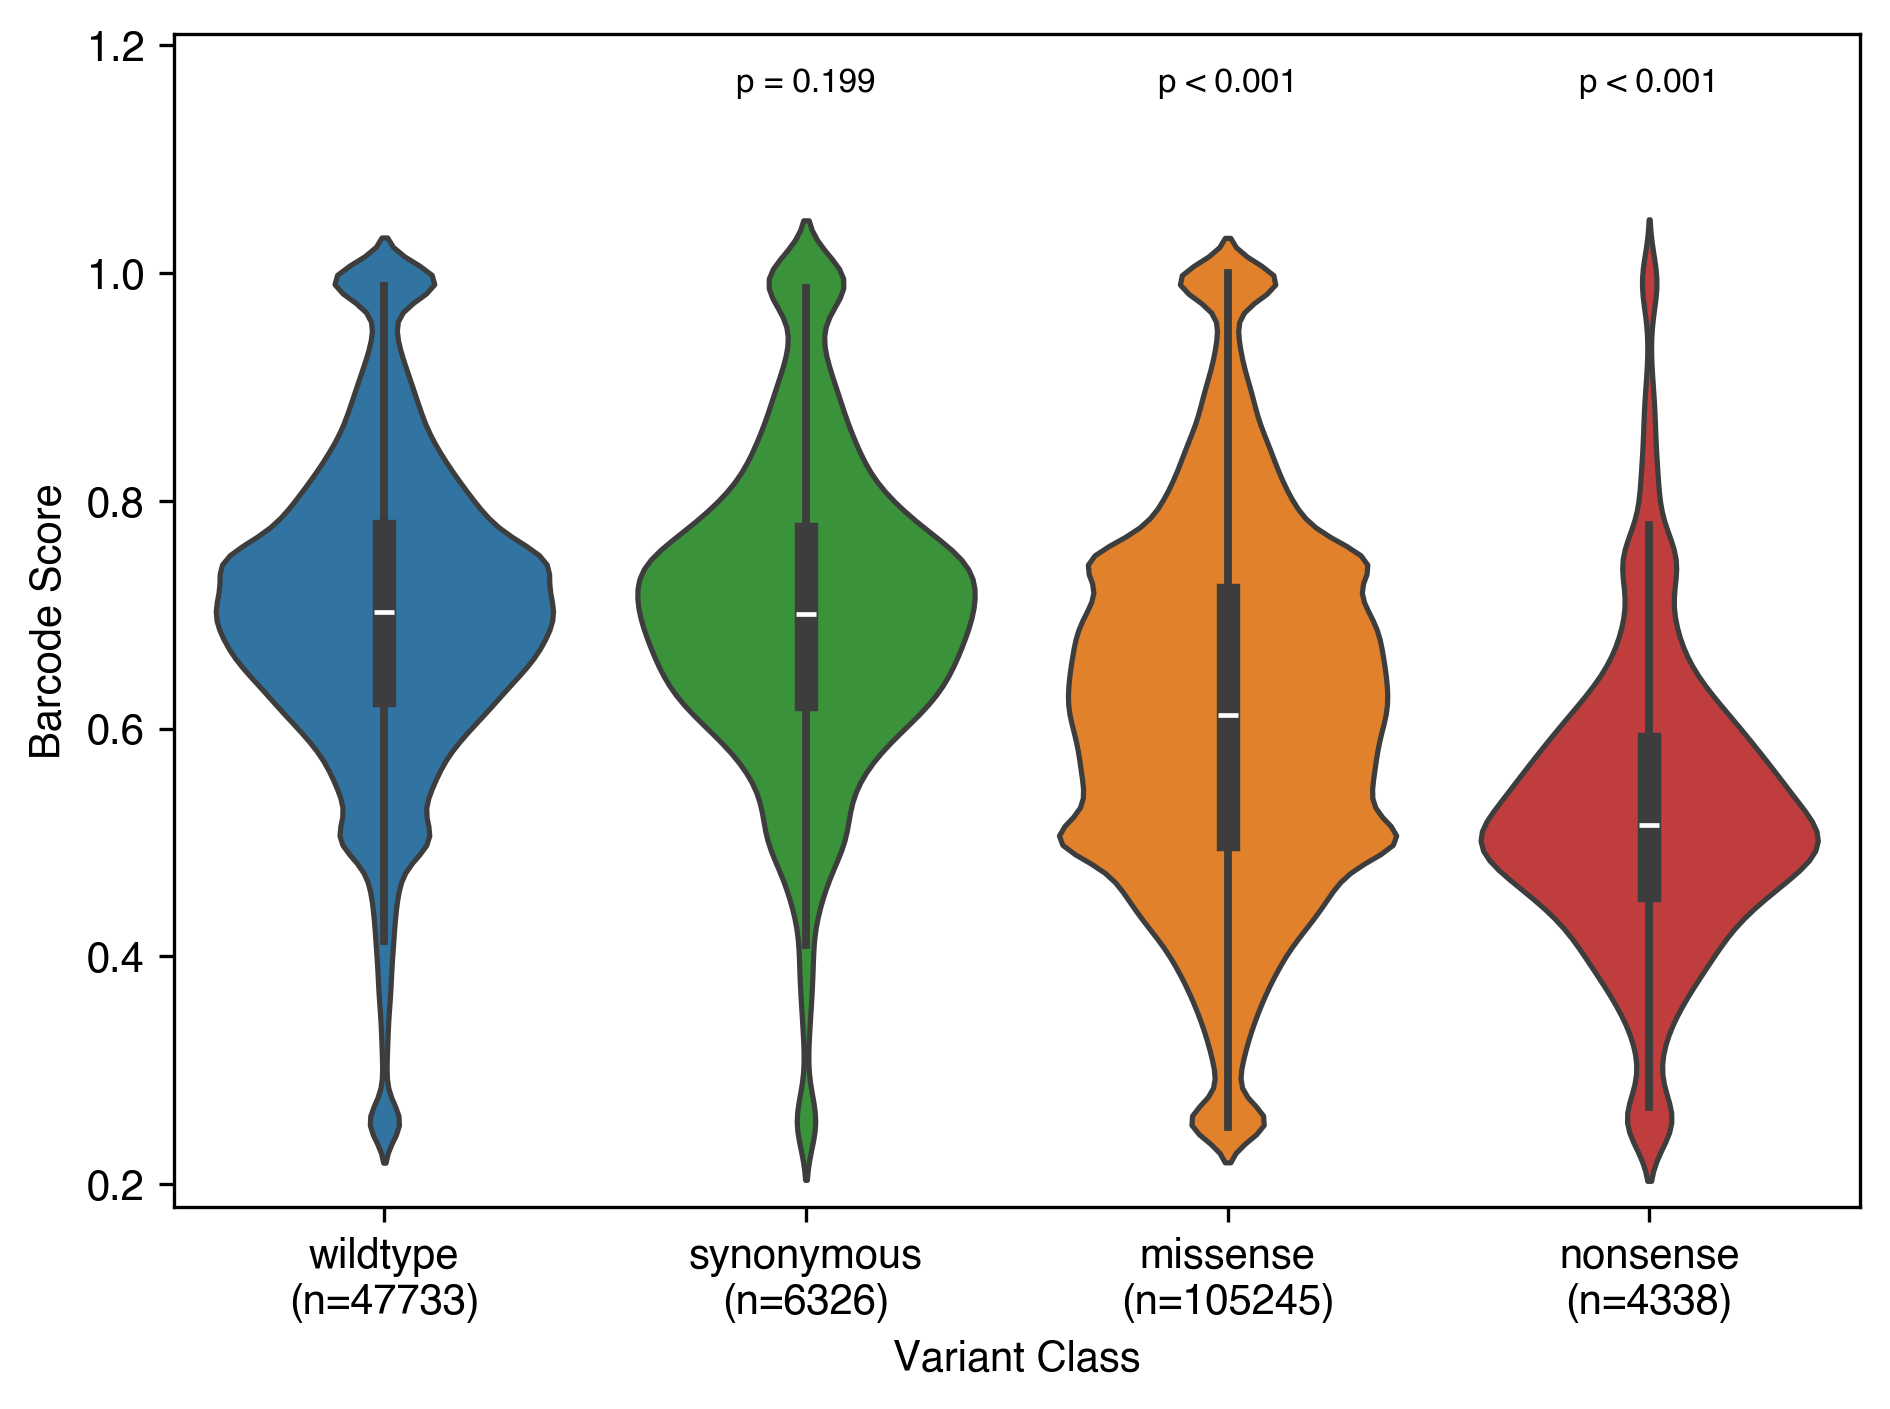

In [73]:
from scipy.stats import mannwhitneyu

class_order = ['wildtype', 'synonymous', 'missense', 'nonsense']
y_col = 'gba1_r1'

# --- sample sizes ---
n_per_class = df_bcScore.groupby('variant_class')[y_col].count().reindex(class_order)

# --- Mann-Whitney U: wildtype vs each other class ---
wt_vals = df_bcScore.loc[df_bcScore['variant_class'] == 'wildtype', y_col].dropna()

mwu_results = {}
for cls in class_order:
    if cls == 'wildtype':
        continue
    other_vals = df_bcScore.loc[df_bcScore['variant_class'] == cls, y_col].dropna()
    stat, pval = mannwhitneyu(wt_vals, other_vals, alternative='two-sided')
    mwu_results[cls] = (stat, pval)
    print(f"wildtype vs {cls}: U = {stat:.1f}, p = {pval:.3g}, n_wt = {len(wt_vals)}, n_{cls} = {len(other_vals)}")

# --- plot ---
fig, ax = plt.subplots()
sns.violinplot(data=df_bcScore, x='variant_class', y=y_col, hue='variant_class',
                order=class_order, ax=ax)
ax.set_ylim(0.18, 1.21)
ax.set_ylabel('Barcode Score')
ax.set_xlabel('Variant Class')

# x tick labels with n
new_labels = [f"{cls}\n(n={n_per_class[cls]})" for cls in class_order]
ax.set_xticklabels(new_labels)

# annotate p-values above wildtype vs each class (skip wildtype itself)
y_max = 1.21
for i, cls in enumerate(class_order):
    if cls == 'wildtype':
        continue
    stat, pval = mwu_results[cls]
    if pval < 0.001:
        p_text = "p < 0.001"
    else:
        p_text = f"p = {pval:.3g}"
    ax.text(i, y_max - 0.03, p_text, ha='center', va='top', fontsize=8)

plt.tight_layout()
plt.savefig('results/scores/barcode_scores_distribution_violin.pdf')

In [74]:
numeric_cols = bc_score.select_dtypes(include='number').columns

bc_score_grpd=bc_score.groupby('aa_substitutions')[numeric_cols].mean().reset_index()

# Select the rows corresponding to 'wildtype' and 'variants' separately
wildtype_score = bc_score_grpd[bc_score_grpd['aa_substitutions'] == 'wildtype']
variants_score = bc_score_grpd[~bc_score_grpd['aa_substitutions'].isin(['wildtype','synonymous'])]

# Drop 'aa_substitutions' column for division
wildtype_values = wildtype_score.drop(columns='aa_substitutions')
variants_values = variants_score.drop(columns='aa_substitutions')

# Perform division
variants_divided_by_wildtype = variants_values.divide(wildtype_values.iloc[0])

# Update 'variants_row' DataFrame with the result
variants_score.loc[:, variants_divided_by_wildtype.columns] = variants_divided_by_wildtype

variants_score['position']=variants_score['aa_substitutions'].apply(lambda x: int(x[1:-1]))
# calculating variant score for avregaes, here is the place to apply weighting
variants_score['gba1_r1']=np.log2(variants_score['gba1_r1'])

#Synonymous variant score calculation ###########
bc_score_syn=bc_score[bc_score['aa_substitutions']=='synonymous']
bc_score_syn
syn_score=bc_score_syn.groupby('codon_substitutions')[numeric_cols].mean().reset_index()
syn_score
syn_score_values = syn_score.drop(columns='codon_substitutions')

# Perform division
syn_divided_by_wildtype = syn_score_values.divide(wildtype_values.iloc[0])

# Update 'variants_row' DataFrame with the result
syn_score.loc[:, syn_divided_by_wildtype.columns] = syn_divided_by_wildtype
syn_score['gba1_r1']=np.log2(syn_score['gba1_r1'])
#########################################################

variants_score_dict={}
variants_score_dict['gba1_r1']=variants_score[['aa_substitutions','gba1_r1']]



variants_score.to_csv('results/scores/variants_scores.csv', index=False)

# Prepare barcode score for FDR calculations
make a df for each experiment, count number of barcodes they have in each replicates, and then rpeat the barcode scores based on their sum of barcode counts in the replicates

In [75]:
df=bc_score[['barcode','aa_substitutions','gba1_r1']]

df['Rep']=1
df.dropna(subset='gba1_r1', inplace=True)

gba1_r1_WtPool=list(df[df['aa_substitutions']=='wildtype']['gba1_r1'])
gba1_r1_VarRepBarCont=df.groupby('aa_substitutions').size().to_dict()
del gba1_r1_VarRepBarCont['wildtype']
del gba1_r1_VarRepBarCont['synonymous']

numeric_cols = df.select_dtypes(include='number').columns
gba1_r1_VarScore=df.groupby('aa_substitutions')[numeric_cols].mean()['gba1_r1'].to_dict()

# Filter out substitutions starting with '*'
filtered_counts = {
    aa_sub: count
    for aa_sub, count in gba1_r1_VarRepBarCont.items()
    if not aa_sub.startswith('*')
}

# Count how many have 1 vs >=2 barcodes
one_barcode = sum(1 for v in filtered_counts.values() if v == 1)
multi_barcode = sum(1 for v in filtered_counts.values() if v >= 2)

print(f"Number of missense single aa substitutions linked with only one barcode: {one_barcode}")
print(f"Number of missense single aa substitutions linked with two or more barcodes: {multi_barcode}")

Number of missense single aa substitutions linked with only one barcode: 573
Number of missense single aa substitutions linked with two or more barcodes: 9837


## bootstap WT scores 10000 times for each experiment

In [76]:
lib_list=['gba1_r1_WtPool']

lib_list_dict={ 'gba1_r1':[gba1_r1_WtPool, gba1_r1_VarRepBarCont, gba1_r1_VarScore]}
                
                
start_time_clock = datetime.now().strftime("%H:%M:%S")
print("Start time:", start_time_clock)


wt_bootstraps={}
for j, library in enumerate(lib_list_dict.keys()):
    
    wt_pool=lib_list_dict[library][0] #list of wt barcode scores
                

    print ('wildtype bootstrapping for ' + library + ' please wait ...')

    print("current time:", datetime.now().strftime("%H:%M:%S")) 
    
    wt_bc_score_dists = {}
    
    highestNumberOfBarcodesPerVariant = df[~df['aa_substitutions'].isin(['wildtype', 'synonymous'])]['aa_substitutions'].value_counts().max()+1 #number of barcodes to sample from the pool


    for i in range (1, highestNumberOfBarcodesPerVariant): #number of barcodes to sample from the pool
        wt_bc_score_avg_bootstrapped=[]
        
        for _ in range(10000): #bootstrapping size
            wt_bc_score_avg_bootstrapped.append(np.mean(random.sample(wt_pool, i)))
            
        wt_bc_score_dists[i]=wt_bc_score_avg_bootstrapped
    
    wt_bootstraps[lib_list[j]]=wt_bc_score_dists
    pd.DataFrame(wt_bc_score_dists).to_csv(f"results/bootstraps/{library}_wildtype_bootstraps.csv")
    
end_time_clock = datetime.now().strftime("%H:%M:%S")
print("Finish time:", end_time_clock)

Start time: 12:40:04
wildtype bootstrapping for gba1_r1 please wait ...
current time: 12:40:04
Finish time: 12:40:24


## Calculate FDRvalues based on barcode scores and sum of their barcode counts in the replicates using wildtype bootstraps

In [77]:
#Read wildtype bootstrapping results 

wt_bootstraps_new={}
for library in lib_list_dict.keys():       
    
    df = pd.read_csv(f'results/bootstraps/{library}_wildtype_bootstraps.csv', index_col=0,skiprows=1, names=np.arange(1,highestNumberOfBarcodesPerVariant))

    wt_bootstraps_new[library] = df.to_dict(orient='series')
###

def count_greater_smaller(number, lst):
    listMean=np.mean(lst)
    if number <= listMean:
        less_than_mean = [item for item in lst if item < listMean]
        fdr = sum(1 for item in less_than_mean if item < number)
        lst_size=len(less_than_mean)
        
    if number > listMean:
        more_than_mean = [item for item in lst if item > listMean]
        fdr = sum(1 for item in more_than_mean if item > number)
        lst_size=len(more_than_mean)
    if fdr == 0:
        fdr=1
    return (fdr/lst_size)

exclude_values = ['wildtype', 'stop', 'synonymous']



for library in lib_list_dict.keys():
    
    FDRvalues = {}
    print (f'calculating FDR for {library}, please wait...')
    
    start_time_clock = datetime.now().strftime("%H:%M:%S")
    print("Start time:", start_time_clock)
    
    var_list = list(lib_list_dict[library][2].keys())
    var_list.remove('synonymous')
    var_list.remove('wildtype')
   
    WT_bootstraps=wt_bootstraps_new[library]

    for item in var_list:
        
 
        VarCount=lib_list_dict[library][1][item]
        
        VarScore=lib_list_dict[library][2][item]
        
        wt_bootstraps_list=list(WT_bootstraps[VarCount])
                                            
        fdr_1=count_greater_smaller(VarScore, wt_bootstraps_list)
                                             
        FDRvalues[item] = (fdr_1)
    
    print ("writing FDR values to df ...")
    _df = variants_score_dict[library]
    df2 = variants_score
    _df['FDRvalues']='' # this is to set FDRvalues empty 
    for item, value in FDRvalues.items():
        # Update the 'FDRvalues' column where 'aa_substitutions' matches the current item
        _df.loc[_df['aa_substitutions'] == item, 'FDRvalues'] = value
        df2.loc[df2['aa_substitutions'] == item, f'{library}_FDR'] = value
    
    _df.rename(columns={library: 'variant_score'}, inplace=True)
    
    _df=_df.dropna()
    variants_score_dict[library]=_df

    for library in lib_list_dict:
        variants_score_dict[library].to_csv(f"results/bootstraps/{library}_BArcodeScoresWithFDR.csv", index=False)

df2.to_csv('results/scores/variant_scores_withFDRs.csv')

# ── Add SD, barcode_count, confidence — insert after df2.to_csv(...) ──────────

for library in lib_list_dict.keys():

    # ── Get barcode-level scores for this library ─────────────────────────────
    # lib_list_dict[library][0] = barcode scores dict {barcode: score}
    # lib_list_dict[library][1] = barcode count per variant {variant: count}
    # lib_list_dict[library][2] = variant mean score {variant: mean_score}

    # Reconstruct barcode-level dataframe from lib_list_dict
    bc_records = []
    for variant, count in lib_list_dict[library][1].items():
        if variant in ['wildtype', 'synonymous']:
            continue
        # Get all barcodes associated with this variant
        # (need barcode->variant mapping — use barcode_scored equivalent)
    
    # ── Compute SD per variant from barcode scores ────────────────────────────
    # In GBA1 the barcode scores per variant come from the bootstrapping input
    # Use lib_list_dict[library][2] for mean scores and compute SD from raw barcodes
    
    df_out = variants_score_dict[library].copy()
    df_out.rename(columns={'FDRvalues': 'FDR'}, inplace=True)

    # Barcode count from lib_list_dict
    VarRepBarCont = {
        k: v for k, v in lib_list_dict[library][1].items()
        if k not in ['wildtype', 'synonymous']
    }
    df_out['barcode_count'] = df_out['aa_substitutions'].map(VarRepBarCont)

    # ── Confidence classification ─────────────────────────────────────────────
    def classify_confidence(row):
        fdr   = row['FDR']
        count = row['barcode_count']

        if pd.isna(fdr):
            return 'No score'
        if fdr < 0.05:
            return 'Confident'
        if count >= 3:
            return 'Confident'
        return 'Non-confident'

    df_out['confidence'] = df_out.apply(classify_confidence, axis=1)

    print(f"\n=== Confidence summary ({library}) ===")
    print(df_out['confidence'].value_counts().to_string())
    print(f"\nBarcode count distribution for FDR > 0.05 variants:")
    fdr_nonsig = df_out[df_out['FDR'] > 0.05]
    for n in range(1, 11):
        subset = fdr_nonsig[fdr_nonsig['barcode_count'] == n]
        if len(subset) > 0:
            print(f"  n={n}: {len(subset)} variants")

    variants_score_dict[library] = df_out
    df_out.to_csv(f'results/bootstraps/{library}_BArcodeScoresWithFDR_confidence.csv', index=False)

end_time_clock = datetime.now().strftime("%H:%M:%S")
print("Finish time:", end_time_clock)    

calculating FDR for gba1_r1, please wait...
Start time: 12:40:24
writing FDR values to df ...

=== Confidence summary (gba1_r1) ===
confidence
Confident        9336
Non-confident    1089

Barcode count distribution for FDR > 0.05 variants:
  n=1: 540 variants
  n=2: 549 variants
  n=3: 526 variants
  n=4: 483 variants
  n=5: 386 variants
  n=6: 296 variants
  n=7: 305 variants
  n=8: 268 variants
  n=9: 242 variants
  n=10: 220 variants
Finish time: 12:40:45


wt mean: 0.7004074619195831
synonymous mean: 0.6998708676394139
  mannwhitneyu between synonymous and wildtype variants (gba1_r1):
  Number of synonymous variants: 6326
  Number of wildtype variants: 47733
  mannwhitneyu-statistic: 149480768.5000
  P-value: 0.1988
aa_substitutions
*537A     2
*537C     4
*537D     1
*537F     4
*537G    12
         ..
Y79R     19
Y79S     33
Y79T     17
Y79V     17
Y79W      9
Length: 10425, dtype: int64


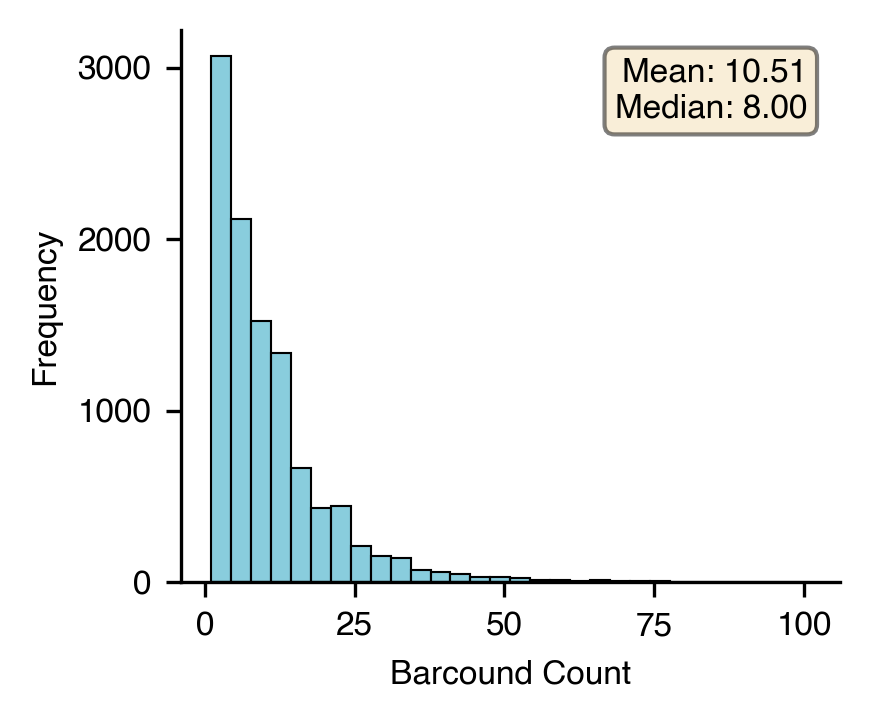

In [78]:
# Create figure with a single subplot
fig, ax = plt.subplots(1, 1, figsize=(3, 2.5))

library = 'gba1_r1'
title = 'gba1_r1'

temp_df = barcode_scored[library]
temp_df_syn_score = list(temp_df[temp_df['variant_class'].isin(['synonymous'])]['barcode_weighted_avg'])
temp_df_wt_score = list(temp_df[temp_df['variant_class'].isin(['wildtype'])]['barcode_weighted_avg'])

# Perform t-test
print(f'wt mean: {np.mean(temp_df_wt_score)}')
print(f'synonymous mean: {np.mean(temp_df_syn_score)}')
t_stat, p_value = stats.mannwhitneyu(temp_df_syn_score, temp_df_wt_score)

print(f"  mannwhitneyu between synonymous and wildtype variants ({library}):")
print(f"  Number of synonymous variants: {len(temp_df_syn_score)}")
print(f"  Number of wildtype variants: {len(temp_df_wt_score)}")
print(f"  mannwhitneyu-statistic: {t_stat:.4f}")
print(f"  P-value: {p_value:.4f}")

temp_df = temp_df[~temp_df['variant_class'].isin(['wildtype', 'synonymous'])]
counts = temp_df.groupby('aa_substitutions').size()

mean_count = counts.mean()
median_count = counts.median()
print(counts)

# Plot histogram
sns.histplot(counts, bins=30, ax=ax, color='#61BDD2')
ax.set_xlabel("Barcound Count", fontsize=8)
ax.set_ylabel("Frequency", fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.yticks(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# Add statistics text
ax.text(0.95, 0.95, f'Mean: {mean_count:.2f}\nMedian: {median_count:.2f}',
        transform=ax.transAxes, verticalalignment='top',
        horizontalalignment='right', fontsize=8,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# plot heatmaps
## first format dataframes, pivoting to dfs to have positions in rows and 20 amino acids list in columns

In [79]:
geneseq='atggagttttcaagtccttccagagaggaatgtcccaagcctttgagtagggtaagcatcatggctggcagcctcacaggattgcttctacttcaggcagtgtcgtgggcatcaggtgcccgcccctgcatccctaaaagcttcggctacagctcggtggtgtgtgtctgcaatgccacatactgtgactcctttgaccccccgacctttcctgcccttggtaccttcagccgctatgagagtacacgcagtgggcgacggatggagctgagtatggggcccatccaggctaatcacacgggcacaggcctgctactgaccctgcagccagaacagaagttccagaaagtgaagggatttggaggggccatgacagatgctgctgctctcaacatccttgccctgtcaccccctgcccaaaatttgctacttaaatcgtacttctctgaagaaggaatcggatataacatcatccgggtacccatggccagctgtgacttctccatccgcacctacacctatgcagacacccctgatgatttccagttgcacaacttcagcctcccagaggaagataccaagctcaagatacccctgattcaccgagccctgcagttggcccagcgtcccgtttcactccttgccagcccctggacatcacccacttggctcaagaccaatggagcggtgaatgggaaggggtcactcaagggacagcccggagacatctaccaccagacctgggccagatactttgtgaagttcctggatgcctatgctgagcacaagttacagttctgggcagtgacagctgaaaatgagccttctgctgggctgttgagtggataccccttccagtgcctgggcttcacccctgaacatcagcgagacttcattgcccgtgacctaggtcctaccctcgccaacagtactcaccacaatgtccgcctactcatgctggatgaccaacgcttgctgctgccccactgggcaaaggtggtactgacagacccagaagcagctaaatatgttcatggcattgctgtacattggtacctggactttctggctccagccaaagccaccctaggggagacacaccgcctgttccccaacaccatgctctttgcctcagaggcctgtgtgggctccaagttctgggagcagagtgtgcggctaggctcctgggatcgagggatgcagtacagccacagcatcatcacgaacctcctgtaccatgtggtcggctggaccgactggaaccttgccctgaaccccgaaggaggacccaattgggtgcgtaactttgtcgacagtcccatcattgtagacatcaccaaggacacgttttacaaacagcccatgttctaccaccttggccacttcagcaagttcattcctgagggctcccagagagtggggctggttgccagtcagaagaacgacctggacgcagtggcactgatgcatcccgatggctctgctgttgtggtcgtgctaaaccgctcctctaaggatgtgcctcttaccatcaaggatcctgctgtgggcttcctggagacaatctcacctggctactccattcacacctacctgtggcgtcgccagtga'
aa_seq = Seq(geneseq).translate()
aa_seq

AA_LIST=sfmap_normal.AA_LIST

def get_PosWTaaVARaa(aa_substitutions):
        pos = int(aa_substitutions[1:-1])
        wt_aa = aa_substitutions[:1]
        variant_aa = aa_substitutions[-1:]
        return wt_aa, pos, variant_aa

def pivot_df(df):

    df['wt_aa'], df['position'], df['variant_aa'] = zip(*df['aa_substitutions'].apply(get_PosWTaaVARaa))
    

    #pivot df for heatmapt plotting
    df_score=pd.pivot_table(df,
                   index='position', 
                   columns='variant_aa', 
                   values='variant_score').reset_index()
    
    df_score.columns.name = None

    df_empty = pd.DataFrame(
    index=range(1, len(aa_seq)+1),  # positions 1 .. len(aa_seq)-1
    columns=AA_LIST
    ).reset_index()

    # Rename the index column to 'position'
    df_empty = df_empty.rename(columns={"index": "position"})

    df_filled = df_empty.merge(df_score, on="position", how="left", suffixes=('', '_y'))

    # Fill NaNs in df_empty with pivoted values
    for col in AA_LIST:
        df_filled[col] = df_filled[col].combine_first(df_filled[col + "_y"])
        df_filled.drop(columns=[col + "_y"], inplace=True)
    
    df_filled.sort_values('position', ascending=True, inplace=True)
    
    df_filled = df_filled.rename_axis(None, axis=1)
    df_filled.reset_index(drop=True, inplace=True)


    #check if there is missing positions in df
    aa_range = range(1, 537)
    position_set = set(df_filled.position)

    missing_elements = [item for item in aa_range if item not in position_set]
    if len(missing_elements) > 0:
        print("Missing positions from df:", missing_elements)
    
    '''
    if 'FDRvalues' in df.columns: #this will only work for average of replicates variant scores where they have FDR_values not for individual replicates
        df_se=pd.pivot_table(df,
                       index='position', 
                       columns='variant_aa', 
                       values='FDRvalues').reset_index()

        df_se.sort_values('position', ascending=True, inplace=True)


        #check if there is missing positions in df
        position_set = set(df_se.position)

        missing_elements = [item for item in aa_range if item not in position_set]
        if len(missing_elements) > 1:
            print("Missing positions from df:", missing_elements)
    '''
    df_filled['median_score']=df_filled[AA_LIST].median(axis=1)
    df_filled['mean_score']=df_filled[AA_LIST].mean(axis=1)
    return df_filled


## pivot average variant scores and store in variantsScore_melt dictionary

In [80]:


variantsScore_melt={}
for library in variants_score_dict.keys(): 
    
    df_singles=variants_score_dict[library]
    
    df_singles=df_singles[~df_singles['aa_substitutions'].isin(['synonymous','wildtype'])].reset_index(drop=True)
    df_singles.rename(columns={'gba1_r1': 'variant_score'}, inplace=True)
    
    df_melt=pivot_df(df_singles)
    
    
    variantsScore_melt[library]=df_melt
    variants_score_dict[library]=df_singles

    df_melt['wt_aa'] = df_melt['position'].apply(lambda x: aa_seq[x - 1] if pd.notnull(x) and x > 0 else None)

    df_melt.to_csv('gba1_app/data/variants_scores.csv', index=False)


In [81]:
aa_list = df_melt['wt_aa'].tolist()
aa_string = ''.join(aa_list)

print(aa_string)

MEFSSPSREECPKPLSRVSIMAGSLTGLLLLQAVSWASGARPCIPKSFGYSSVVCVCNATYCDSFDPPTFPALGTFSRYESTRSGRRMELSMGPIQANHTGTGLLLTLQPEQKFQKVKGFGGAMTDAAALNILALSPPAQNLLLKSYFSEEGIGYNIIRVPMASCDFSIRTYTYADTPDDFQLHNFSLPEEDTKLKIPLIHRALQLAQRPVSLLASPWTSPTWLKTNGAVNGKGSLKGQPGDIYHQTWARYFVKFLDAYAEHKLQFWAVTAENEPSAGLLSGYPFQCLGFTPEHQRDFIARDLGPTLANSTHHNVRLLMLDDQRLLLPHWAKVVLTDPEAAKYVHGIAVHWYLDFLAPAKATLGETHRLFPNTMLFASEACVGSKFWEQSVRLGSWDRGMQYSHSIITNLLYHVVGWTDWNLALNPEGGPNWVRNFVDSPIIVDITKDTFYKQPMFYHLGHFSKFIPEGSQRVGLVASQKNDLDAVALMHPDGSAVVVVLNRSSKDVPLTIKDPAVGFLETISPGYSIHTYLWRRQ*


## plot heatmaps, select average or single replicates

In [82]:
import sys
sys.modules.pop("sfmap_normal", None)
import sfmap_normal
for library in variantsScore_melt.keys():
    
    #if library[-3:] == 'avg': continue #turn this on if you want only plot replictes
    #if library[-3:] != 'avg': continue #turn this on if you want only plot averages
    
    df_score=variantsScore_melt[library]
    
    for i, j in enumerate(aa_seq):
        df_score.at[i, j] = 0
    
    
    pdf = PdfPages(f'results/figures/heatmaps/{library}_heatmap_.pdf')

    df_score.reset_index(drop=True, inplace=True)


    vmin = -0.8
    vmax = 0.5
    
    print (f'plotting heatmap for {library}, wait...')
    # Call the sfmap_plot function
    sfmap_normal.sfmap_plot(df_score[AA_LIST], pdf, "scores", aa_seq, (5,133),
            #df_se=df_se[AA_LIST],
            sfmap_name= name_map[library] ,
            show_colorbar=True,
            show_positions=True,
            show_variants=True,
            show_wt=True,
            aa_list=AA_LIST,
            aa_label_groups=[],
            vmin=vmin,
            vmax=vmax        )
    # Close the pdf object
    pdf.close()

    print ('done!')

plotting heatmap for gba1_r1, wait...


done!


% non-significant nonsense variants with <3 barcodes: 60%
Barcode-count Mann–Whitney U p-value: 2.12e-36
Barcode-score SD Mann–Whitney U p-value: 1.01e-02


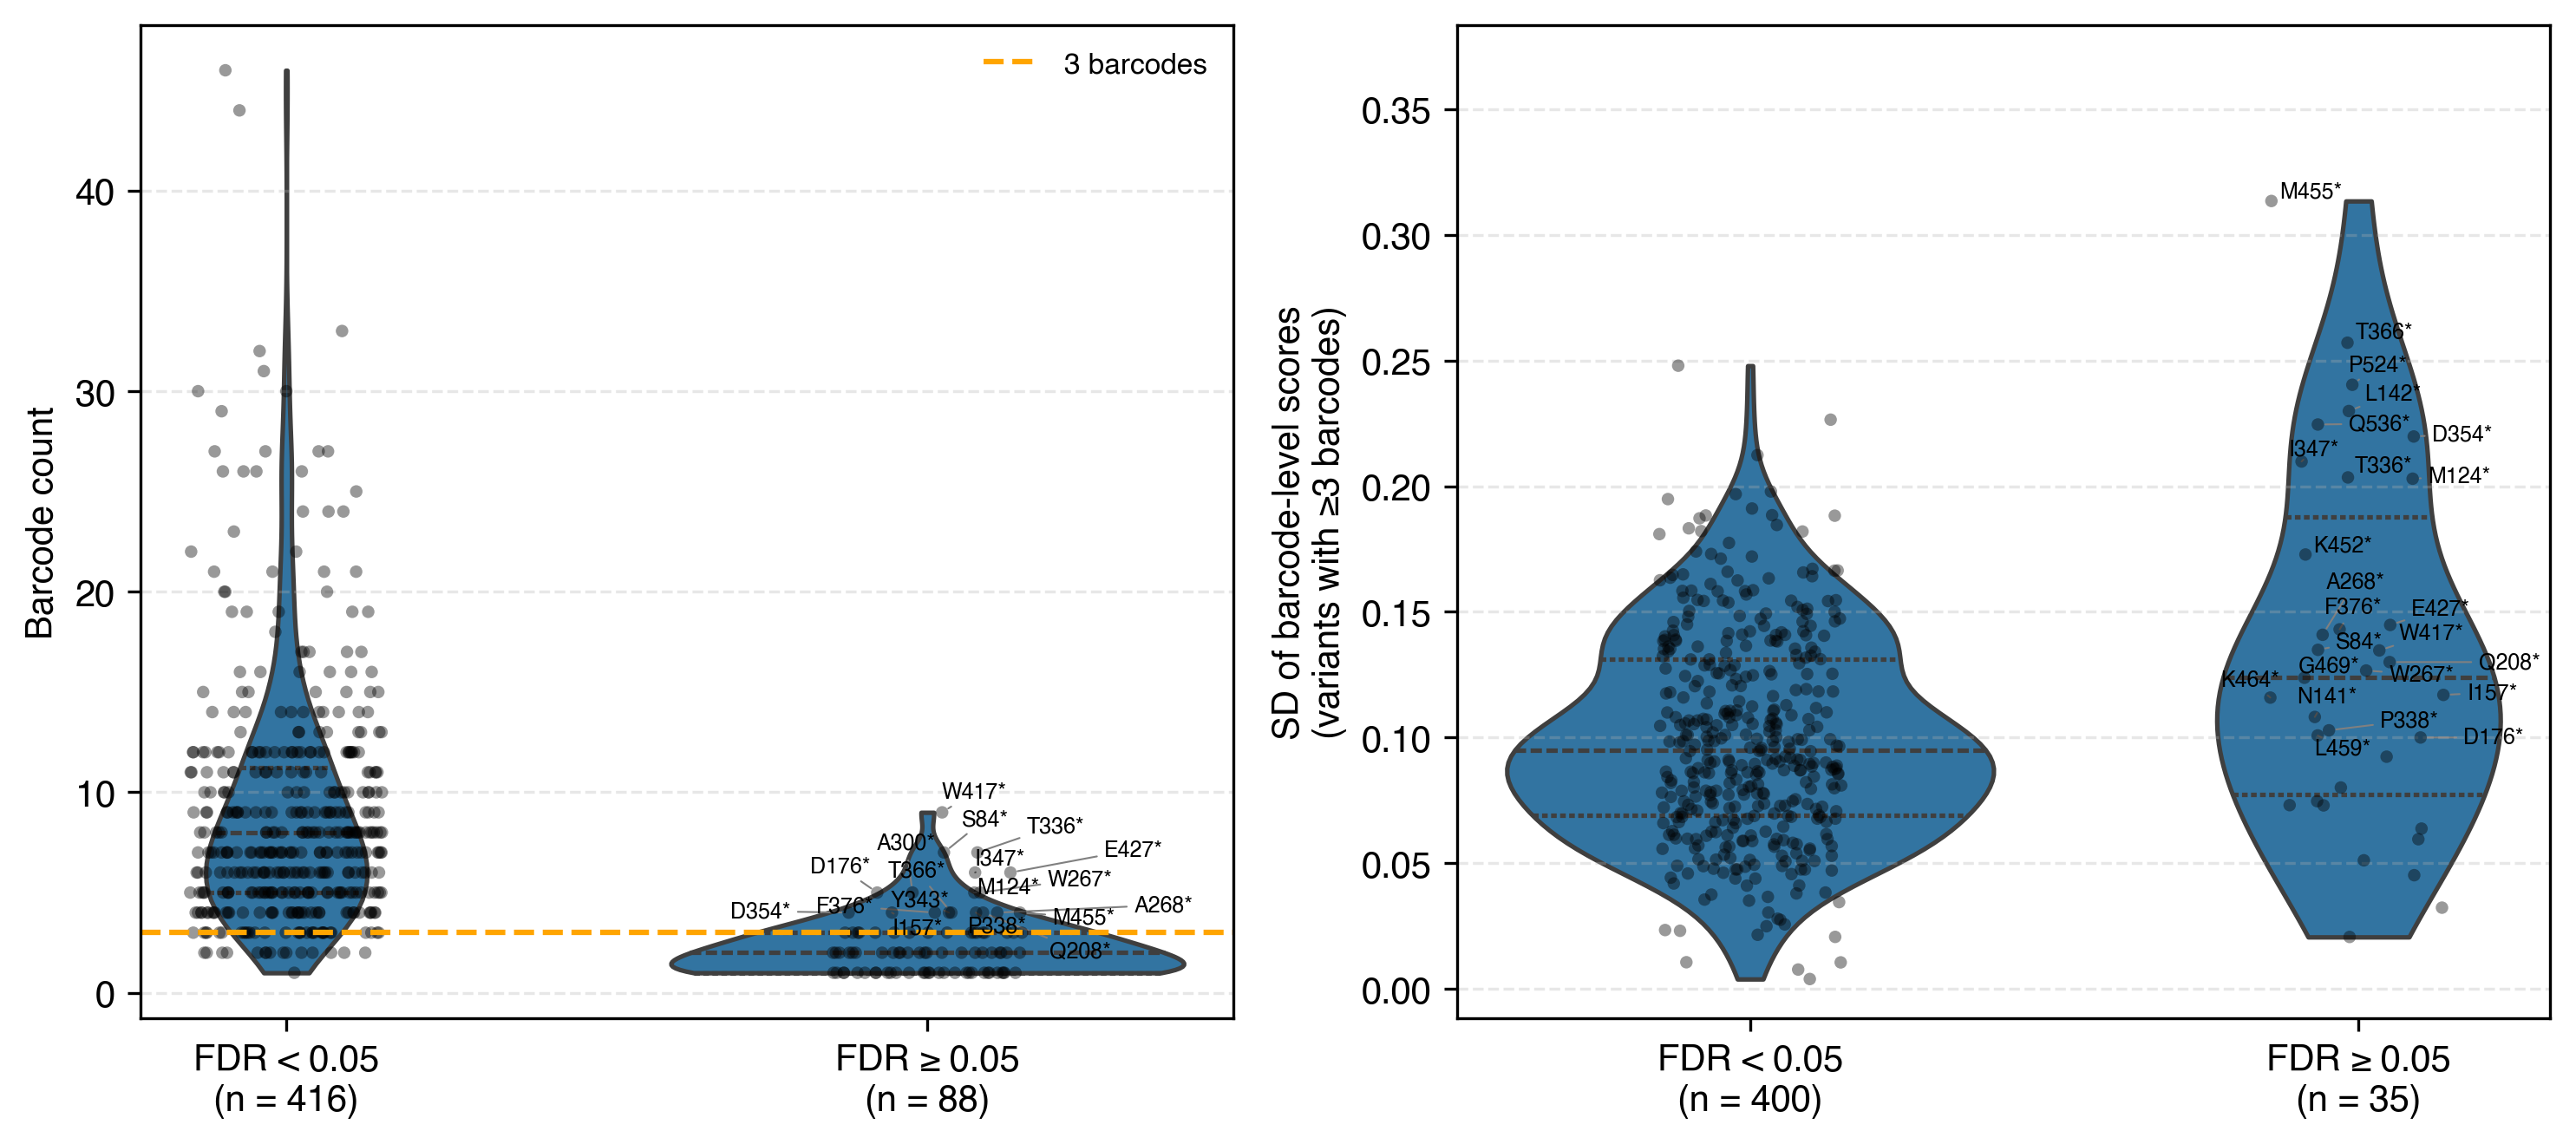

In [83]:
library = 'gba1_r1'
score_col = 'gba1_r1'
MIN_BARCODES = 3

order = ['FDR < 0.05', 'FDR ≥ 0.05']
x_pos = {group: i for i, group in enumerate(order)}

# ── Nonsense-variant FDR information ─────────────────────────────────────────
variant_info = variants_score_dict[library].copy()
variant_info = variant_info[
    (variant_info['position'] > 21) &
    (variant_info['aa_substitutions'].str.endswith('*', na=False)) &
    (variant_info['FDR'].notna())
][['aa_substitutions', 'FDR', 'barcode_count']].drop_duplicates()

variant_info['significant'] = np.where(
    variant_info['FDR'] < 0.05,
    'FDR < 0.05',
    'FDR ≥ 0.05'
)

# ── Left panel: barcode count by FDR group ────────────────────────────────────
stop = variant_info.copy()

stop_sig = stop[stop['significant'] == 'FDR < 0.05']
stop_nonsig = stop[stop['significant'] == 'FDR ≥ 0.05']

stat_count, p_count = mannwhitneyu(
    stop_sig['barcode_count'],
    stop_nonsig['barcode_count'],
    alternative='two-sided'
)

low_bc_frac = (stop_nonsig['barcode_count'] < 3).mean()

print(f'% non-significant nonsense variants with <3 barcodes: {low_bc_frac * 100:.0f}%')
print(f'Barcode-count Mann–Whitney U p-value: {p_count:.2e}')

# Controlled jitter for the left panel
rng_left = np.random.default_rng(0)
stop['x_jitter'] = (
    stop['significant'].map(x_pos)
    + rng_left.uniform(-0.15, 0.15, size=len(stop))
)

# ── Right panel: SD of barcode-level scores by FDR group ──────────────────────
barcode_df = bc_score.copy()
barcode_df = barcode_df[
    barcode_df['aa_substitutions'].isin(variant_info['aa_substitutions'])
].dropna(subset=[score_col])

sd_df = (
    barcode_df
    .groupby('aa_substitutions')[score_col]
    .agg(
        barcode_count='count',
        barcode_score_sd=lambda x: x.std(ddof=1)
    )
    .reset_index()
)

sd_df = sd_df[sd_df['barcode_count'] >= MIN_BARCODES]
sd_df = sd_df.merge(
    variant_info[['aa_substitutions', 'FDR', 'significant']],
    on='aa_substitutions',
    how='inner'
)

sig_sd = sd_df.loc[
    sd_df['significant'] == 'FDR < 0.05',
    'barcode_score_sd'
]
nonsig_sd = sd_df.loc[
    sd_df['significant'] == 'FDR ≥ 0.05',
    'barcode_score_sd'
]

stat_sd, p_sd = mannwhitneyu(sig_sd, nonsig_sd, alternative='two-sided')
print(f'Barcode-score SD Mann–Whitney U p-value: {p_sd:.2e}')

# Controlled jitter for the right panel
rng_right = np.random.default_rng(1)
sd_df['x_jitter'] = (
    sd_df['significant'].map(x_pos)
    + rng_right.uniform(-0.15, 0.15, size=len(sd_df))
)

# ── Combined figure ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
ax_left, ax_right = axes

# LEFT: barcode counts
sns.violinplot(
    data=stop,
    x='significant',
    y='barcode_count',
    order=order,
    cut=0,
    inner='quartile',
    color='#1f77b4',
    ax=ax_left
)

ax_left.scatter(
    stop['x_jitter'],
    stop['barcode_count'],
    color='black',
    alpha=0.4,
    s=12,
    zorder=2,
    edgecolors='none'
)

# Label non-significant variants with ≥4 barcodes
left_labels = stop[
    (stop['significant'] == 'FDR ≥ 0.05') &
    (stop['barcode_count'] >= 4)
]

left_texts = [
    ax_left.text(
        row['x_jitter'],
        row['barcode_count'],
        row['aa_substitutions'],
        fontsize=6
    )
    for _, row in left_labels.iterrows()
]

adjust_text(
    left_texts,
    ax=ax_left,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
)

left_counts = stop.groupby('significant').size().reindex(order)
ax_left.set_xticks([0, 1])
ax_left.set_xticklabels([
    f'FDR < 0.05\n(n = {left_counts.iloc[0]})',
    f'FDR ≥ 0.05\n(n = {left_counts.iloc[1]})'
])
ax_left.axhline(3, color='orange', linestyle='--', linewidth=1.5, label='3 barcodes')
ax_left.set_xlabel('')
ax_left.set_ylabel('Barcode count')
ax_left.grid(True, alpha=0.3, linestyle='--', axis='y')
ax_left.legend(fontsize=8, frameon=False)

# RIGHT: within-variant barcode-score SD
sns.violinplot(
    data=sd_df,
    x='significant',
    y='barcode_score_sd',
    order=order,
    color='#1f77b4',
    cut=0,
    inner='quartile',
    ax=ax_right
)

ax_right.scatter(
    sd_df['x_jitter'],
    sd_df['barcode_score_sd'],
    color='black',
    alpha=0.4,
    s=12,
    zorder=2,
    edgecolors='none'
)

# Label high-SD non-significant variants
right_labels = sd_df[
    (sd_df['significant'] == 'FDR ≥ 0.05') &
    (sd_df['barcode_score_sd'] >= 0.10)
]

right_texts = [
    ax_right.text(
        row['x_jitter'],
        row['barcode_score_sd'],
        row['aa_substitutions'],
        fontsize=6
    )
    for _, row in right_labels.iterrows()
]

adjust_text(
    right_texts,
    ax=ax_right,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
)

right_counts = sd_df.groupby('significant').size().reindex(order)
ax_right.set_xticks([0, 1])
ax_right.set_xticklabels([
    f'FDR < 0.05\n(n = {right_counts.iloc[0]})',
    f'FDR ≥ 0.05\n(n = {right_counts.iloc[1]})'
])

ax_right.set_xlabel('')
ax_right.set_ylabel(
    f'SD of barcode-level scores\n(variants with ≥{MIN_BARCODES} barcodes)'
)
ax_right.grid(True, alpha=0.3, linestyle='--', axis='y')

# p-value bracket for SD comparison
y_min, y_max = ax_right.get_ylim()
y_range = y_max - y_min
bracket_y = y_max + 0.04 * y_range
bracket_h = 0.03 * y_range

#add pvalue to the the plot
'''
ax_right.plot(
    [0, 0, 1, 1],
    [bracket_y, bracket_y + bracket_h, bracket_y + bracket_h, bracket_y],
    color='black',
    lw=0.8,
    clip_on=False
)

ax_right.text(
    0.5,
    bracket_y + bracket_h,
    f'p = {p_sd:.2g}',
    ha='center',
    va='bottom',
    fontsize=8
)
'''
ax_right.set_ylim(top=bracket_y + 4 * bracket_h)

fig.tight_layout()
fig.savefig(
    'results/figures/FigS_nonsense_barcode_count_and_score_SD_by_FDR.pdf',
    bbox_inches='tight'
)

plt.show()

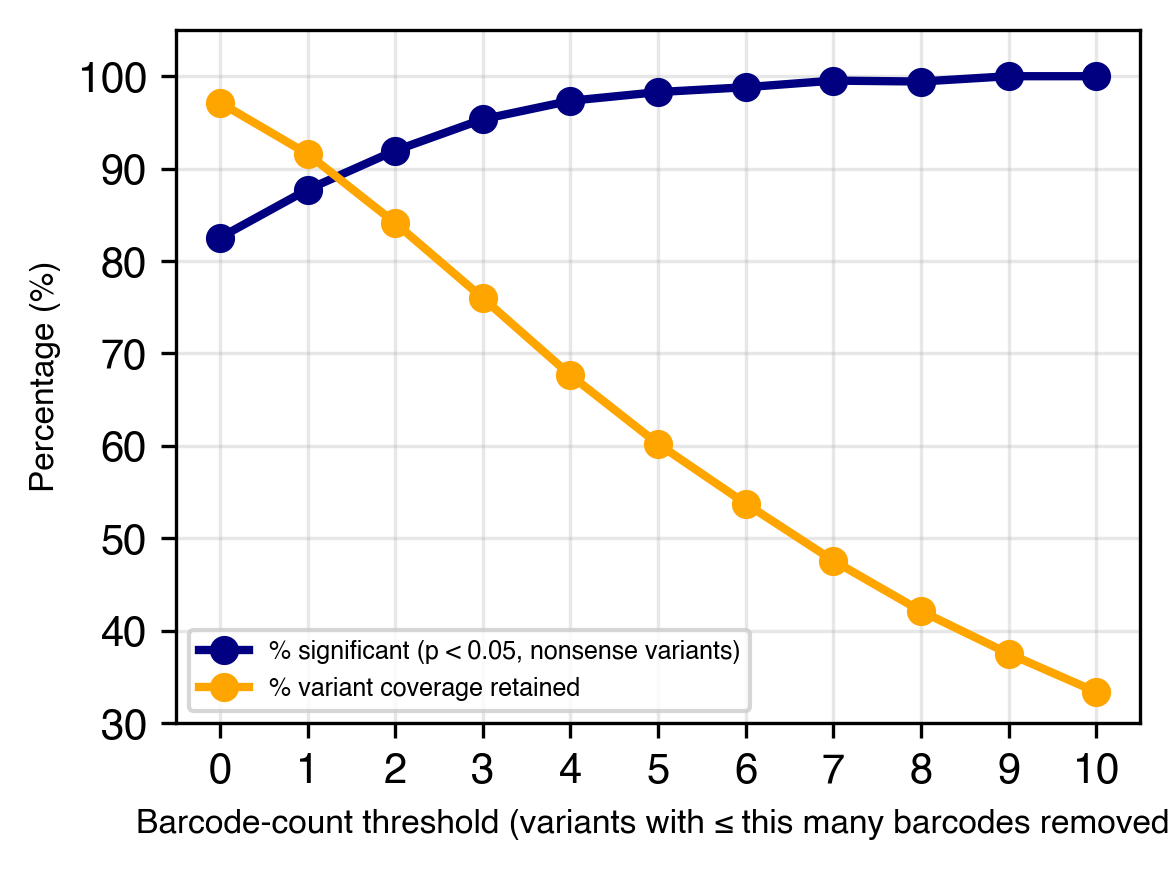

Restricting the analysis to variants with ≥3 barcodes increased the fraction of significant nonsense variants from 82.5% to 92.0%, while reducing the fraction of variants retained from 97.1% to 84.1%.


In [84]:
from matplotlib.ticker import MultipleLocator

TOTAL_EXPECTED = 516 * 20   # 516 positions x 20 possible changes each (19 aa + stop) = 10320
MAX_THRESHOLD = 10

variants_score_dict_no21 = variants_score_dict['gba1_r1'].copy()
variants_score_dict_no21 = variants_score_dict_no21[variants_score_dict_no21['position'] > 21]

stop = variants_score_dict_no21[
    variants_score_dict_no21['aa_substitutions'].str.endswith('*', na=False)
]

thresholds = list(range(0, MAX_THRESHOLD + 1))   # 0 = baseline, nothing removed
pct_sig_list = []
coverage_list = []

for t in thresholds:
    # % significant: still computed on stop-codon variants only
    filtered_stop = stop[stop['barcode_count'] > t]
    pct_sig = (filtered_stop['FDR'] < 0.05).sum() / len(filtered_stop) * 100 if len(filtered_stop) else float('nan')
    pct_sig_list.append(pct_sig)

    # coverage: unique amino-acid changes (ALL types, incl. stop) retained,
    # out of the full expected library of 516 positions x 20 changes
    filtered_all = variants_score_dict_no21[variants_score_dict_no21['barcode_count'] > t]
    n_changes_covered = filtered_all['aa_substitutions'].nunique()
    coverage_list.append((n_changes_covered / TOTAL_EXPECTED) * 100)

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(thresholds, pct_sig_list, color='navy', marker='o', linewidth=2,
        label='% significant (p < 0.05, nonsense variants)')
ax.plot(thresholds, coverage_list, color='orange', marker='o', linewidth=2,
        label='% variant coverage retained')

ax.set_xlabel('Barcode-count threshold (variants with ≤ this many barcodes removed)', fontsize=8)
ax.set_ylabel('Percentage (%)', fontsize=8)
ax.set_xticks(thresholds)
ax.set_xlim(-0.5, MAX_THRESHOLD+0.5)
ax.set_ylim(30, 105)
ax.yaxis.set_major_locator(MultipleLocator(10))
ax.legend(loc='lower left', fontsize=6)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/figures/bc_Count_and_MutCoverage.pdf")
plt.show()

# ≥3 barcodes means removing variants with 0–2 barcodes (threshold t = 2)
baseline_i = thresholds.index(0)
three_bc_i = thresholds.index(2)

print(
    "Restricting the analysis to variants with ≥3 barcodes increased the "
    f"fraction of significant nonsense variants from {pct_sig_list[baseline_i]:.1f}% "
    f"to {pct_sig_list[three_bc_i]:.1f}%, while reducing the fraction of variants "
    f"retained from {coverage_list[baseline_i]:.1f}% to "
    f"{coverage_list[three_bc_i]:.1f}%."
)

## color structure

In [85]:
pdb_file = "input_files/2NSX.pdb"
for record in SeqIO.parse(pdb_file, "pdb-atom"):
    print("chain: " + record.id.split(":")[1])
    print(record.seq)
    
    
def pdb_to_csv(pdb):
    df_pdb = pd.DataFrame(columns=["id", "atom_no", "atom", "res", "chain", "res_no",
                               "x", "y", "z", "factor_a", "bfactor", "atom_center"])
    with open(pdb) as pdbfile:
        i = 0
        for line in pdbfile:
            if line[:4] == 'ATOM' or line[:6] == "HETATM":
                splitted_line = [line[:6], line[6:11], line[12:16], line[17:20], line[21], line[22:26],
                             line[30:38], line[38:46], line[46:54], line[54:60], line[60:66], line[66:78]]
                df_pdb.loc[i] = splitted_line
                i += 1
    df_id = df_pdb["id"].str.strip()
    df_atom_no = df_pdb["atom_no"].str.strip()
    df_atom = df_pdb["atom"].str.strip()
    df_res = df_pdb["res"].str.strip()
    df_chain = df_pdb["chain"].str.strip()
    df_res_no = df_pdb["res_no"].str.strip()
    df_res_no = df_res_no.astype(int)
    df_x = df_pdb["x"].str.strip()
    df_y = df_pdb["y"].str.strip()
    df_z = df_pdb["z"].str.strip()
    df_factor_a = df_pdb["factor_a"].str.strip()
    df_bfactor = df_pdb["bfactor"].str.strip()
    df_bfactor = df_bfactor.astype(float)
    df_atom_center = df_pdb["atom_center"].str.strip()
    df = pd.concat([df_id, df_atom_no, df_atom, df_res, df_chain, df_res_no,
                   df_x, df_y, df_z, df_factor_a, df_bfactor, df_atom_center], axis = 1)
    return df  

def domain_partitioner(df_csv):
    Selected_columns=["id", "atom_no", "atom", "res", "chain", "res_no","x", "y", "z", "factor_a", "bfactor", "atom_center"]
    df_A = pd.DataFrame(columns=Selected_columns)
    df_C = pd.DataFrame(columns=Selected_columns)
    df_D = pd.DataFrame(columns=Selected_columns)
    df_E = pd.DataFrame(columns=Selected_columns)
    df_F = pd.DataFrame(columns=Selected_columns)
    df_G = pd.DataFrame(columns=Selected_columns)
    
    
    
    ix = 0
    for c in range(len(df_csv["id"])):
        #domain A
        if df_csv["chain"][c]=="A":
            df_A.loc[ix] = df_csv.iloc[c]  
        #domain C
        elif df_csv["chain"][c]=="C":
            df_C.loc[ix] = df_csv.iloc[c]  
        #domain D
        elif df_csv["chain"][c]=="D":
            df_D.loc[ix] = df_csv.iloc[c] 
        #domain E
        elif df_csv["chain"][c]=="E":
            df_E.loc[ix] = df_csv.iloc[c]
        #domain A
        elif df_csv["chain"][c]=="F":
            df_F.loc[ix] = df_csv.iloc[c]
        elif df_csv["chain"][c]=="G":
            df_G.loc[ix] = df_csv.iloc[c]
        
  
            
        ix = ix+1  
    return df_A, df_C, df_D, df_E, df_F, df_G

def bfactor_overwriter_6PXV(pdb, data):
    df_csv = pdb_to_csv(pdb)
    
   
    df_csv['res_no'] = df_csv.apply(lambda row:  row['res_no']+39, axis=1)
   
    
    result_df = df_csv.copy()
    #==============================
    
    a, c, d, e,f,g = domain_partitioner(result_df)

 
    #this is to adjust residue numbering in pdb file
    df_data = data
    df_a = a.merge(df_data, left_on = "res_no", right_on = "position")
    df_c = c.merge(df_data, left_on = "res_no", right_on = "position")


    df_a = df_a[["id", "atom_no", "atom", "res", "chain", "res_no","x", "y", "z", "factor_a", "median_score", "atom_center"]]
    df_c = df_c[["id", "atom_no", "atom", "res", "chain", "res_no","x", "y", "z", "factor_a", "median_score", "atom_center"]]

    
    df_d=d.rename({'bfactor':'median_score'}, axis=1)
    df_e=e.rename({'bfactor':'median_score'}, axis=1)
    df_f=f.rename({'bfactor':'median_score'}, axis=1)
    df_g=g.rename({'bfactor':'median_score'}, axis=1)
    
 

    df = pd.concat([df_a, df_c, df_d, df_e, df_f, df_g], axis = 0)
    
    print("Process completed")
    return df



##############################################
df_exp = variantsScore_melt['gba1_r1']


df_exp = df_exp[['position','median_score']]

df_end=bfactor_overwriter_6PXV(pdb = pdb_file, data = df_exp)


df_end.to_csv('results/PDB/2NSX.csv', index=False, header=False)

df_end['res_no']=df_end['res_no']-39
df_end.to_csv('results/PDB/2NSX_correctedResNo.csv', index=False, header=False)


# define the AWK command
!awk 'BEGIN{OFS=FS=","}{$7=sprintf("%.3f",$7)}1{$8=sprintf("%.3f",$8)}1{$9=sprintf("%.3f",$9)}1' results/PDB/2NSX.csv | awk 'BEGIN {FS =","; OFS=""} { if(length($3) == 4 ) {pad = sprintf("%s", " ")} else {pad = sprintf("%2s", " ")} } { if(length($3) == 4 ) {pad2 = sprintf("%s", " ")} else {pad2 = sprintf("%s", "")} } {printf "%-6s%5s%s%-4s%s%3s%2s%4s%12s%8s%8s%6s%6s%12s\n", $1, $2, pad, $3, pad2, $4, $5, $6, $7, $8, $9, $10, $11, $12}' > results/PDB/2NSX.pdb
!awk 'BEGIN{OFS=FS=","}{$7=sprintf("%.3f",$7)}1{$8=sprintf("%.3f",$8)}1{$9=sprintf("%.3f",$9)}1' results/PDB/2NSX_correctedResNo.csv | awk 'BEGIN {FS =","; OFS=""} { if(length($3) == 4 ) {pad = sprintf("%s", " ")} else {pad = sprintf("%2s", " ")} } { if(length($3) == 4 ) {pad2 = sprintf("%s", " ")} else {pad2 = sprintf("%s", "")} } {printf "%-6s%5s%s%-4s%s%3s%2s%4s%12s%8s%8s%6s%6s%12s\n", $1, $2, pad, $3, pad2, $4, $5, $6, $7, $8, $9, $10, $11, $12}' > results/PDB/2NSX_correctedResNo.pdb



chain: A
ARPCIPKSFGYSSVVCVCNATYCDSFDPPTFPALGTFSRYESTRSGRRMELSMGPIQANHTGTGLLLTLQPEQKFQKVKGFGGAMTDAAALNILALSPPAQNLLLKSYFSEEGIGYNIIRVPMASCDFSIRTYTYADTPDDFQLHNFSLPEEDTKLKIPLIHRALQLAQRPVSLLASPWTSPTWLKTNGAVNGKGSLKGQPGDIYHQTWARYFVKFLDAYAEHKLQFWAVTAENEPSAGLLSGYPFQCLGFTPEHQRDFIARDLGPTLANSTHHNVRLLMLDDQRLLLPHWAKVVLTDPEAAKYVHGIAVHWYLDFLAPAKATLGETHRLFPNTMLFASEACVGSKFWEQSVRLGSWDRGMQYSHSIITNLLYHVVGWTDWNLALNPEGGPNWVRNFVDSPIIVDITKDTFYKQPMFYHLGHFSKFIPEGSQRVGLVASQKNDLDAVALMHPDGSAVVVVLNRSSKDVPLTIKDPAVGFLETISPGYSIHTYLWHRQ
Process completed


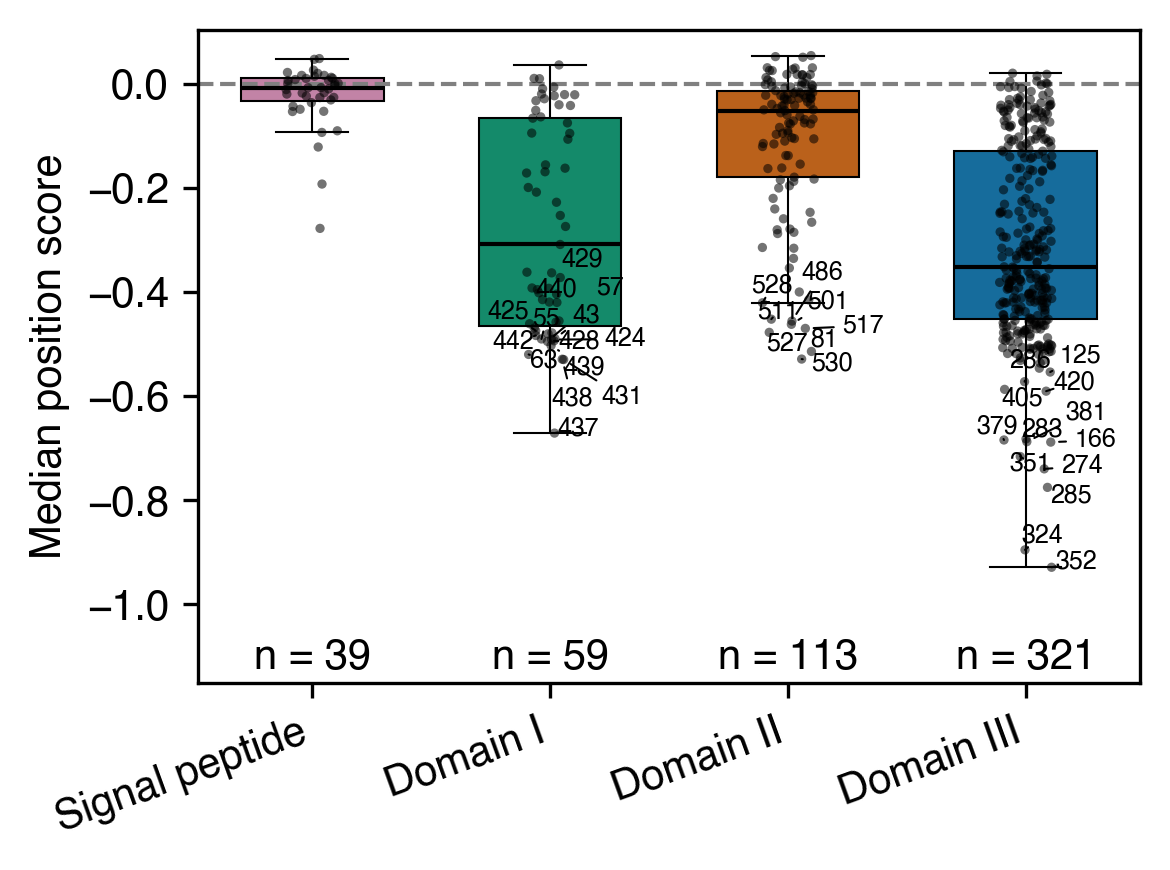

In [86]:
# Domain boundaries (residue ranges), fixed to tuples
signal_peptide = [(1, 39)]
dom1 = [(40, 66), (422, 453)]
dom2 = [(69, 114), (470, 536)]
dom3 = [(115, 420), (455, 469)]   # was "som3" in the old cell

def assign_region(pos):
    for lo, hi in signal_peptide:
        if lo <= pos <= hi:
            return 'Signal peptide'
    for lo, hi in dom1:
        if lo <= pos <= hi:
            return 'Domain 1'
    for lo, hi in dom2:
        if lo <= pos <= hi:
            return 'Domain 2'
    for lo, hi in dom3:
        if lo <= pos <= hi:
            return 'Domain 3'
    return None

plot_df = df_melt[['position', 'median_score']].copy()
plot_df['region'] = plot_df['position'].apply(assign_region)
plot_df = plot_df.dropna(subset=['region']).reset_index(drop=True)

region_colors = {
    'Signal peptide': '#CC79A7',
    'Domain II':       '#D55E00',
    'Domain I':       '#009E73',
    'Domain III':       '#0072B2',
}

rng = np.random.default_rng(0)  # fixed seed = reproducible jitter
jitter_width = 0.22

plot_df = plot_df.copy()
plot_df['region'] = plot_df['region'].replace({
    'Domain 1': 'Domain I',
    'Domain 2': 'Domain II',
    'Domain 3': 'Domain III',
})

region_order = ['Signal peptide', 'Domain I', 'Domain II', 'Domain III']

plot_df['x_base'] = plot_df['region'].map(lambda r: region_order.index(r))
plot_df['x_jitter'] = plot_df['x_base'] + rng.uniform(
    -jitter_width / 2,
    jitter_width / 2,
    size=len(plot_df)
)
plt.figure(figsize=(4, 3))

sns.boxplot(
    data=plot_df,
    x='region',
    y='median_score',
    order=region_order,
    palette=region_colors,
    width=0.6,
    linewidth=0.5,
    fliersize=0,  # outliers are already shown by the manual jittered scatter below
    boxprops=dict(edgecolor='black'),
    medianprops=dict(color='black', linewidth=1),
    whiskerprops=dict(color='black', linewidth=0.5),
    capprops=dict(color='black', linewidth=0.5),
)

# manual "stripplot" using the jitter we control
plt.scatter(
    plot_df['x_jitter'], plot_df['median_score'],
    color='black', alpha=0.55, s=5, zorder=3,
    edgecolors='none'
)

annotation_thresholds = {
    'Domain I': -0.47,
    'Domain II': -0.42,
    'Domain III': -0.55,
}

texts = []
for _, row in plot_df.iterrows():
    threshold = annotation_thresholds.get(row['region'])
    if threshold is not None and row['median_score'] < threshold:
        text = plt.text(
            row['x_jitter'], row['median_score'],
            str(int(row['position'])),
            fontsize=6, color='k'
        )
        texts.append(text)

adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='k', lw=0.5)
)

plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.xlabel('')
plt.ylabel('Median position score')
plt.xticks(rotation=20, ha='right')

#this section add pvalues to the plot
''' 
# Two-sided Mann–Whitney U tests and comparison brackets
comparisons = [
    ('Signal peptide', 'Domain I'),
    ('Signal peptide', 'Domain II'),
    ('Signal peptide', 'Domain III'),
    ('Domain I', 'Domain II'),
    ('Domain II', 'Domain III'),
]

ax = plt.gca()
_, current_ymax = ax.get_ylim()
y_range = current_ymax - ax.get_ylim()[0]

bracket_step = 0.075 * y_range
bracket_height = 0.018 * y_range
first_bracket_y = current_ymax + 0.04 * y_range

for level, (group1, group2) in enumerate(comparisons):
    values1 = plot_df.loc[plot_df['region'] == group1, 'median_score'].dropna()
    values2 = plot_df.loc[plot_df['region'] == group2, 'median_score'].dropna()

    stat, p_value = mannwhitneyu(
        values1,
        values2,
        alternative='two-sided'
    )

    x1 = region_order.index(group1)
    x2 = region_order.index(group2)
    y = first_bracket_y + level * bracket_step

    # Bracket line
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + bracket_height, y + bracket_height, y],
        color='black',
        linewidth=0.8,
        clip_on=False
    )

    # Display exact p-value
    p_label = f'p = {p_value:.2g}'
    ax.text(
        (x1 + x2) / 2,
        y + bracket_height,
        p_label,
        ha='center',
        va='bottom',
        fontsize=6,
        clip_on=False
    )

# Leave space above plot for all six comparisons
ax.set_ylim(top=first_bracket_y + len(comparisons) * bracket_step + 0.06 * y_range)
'''

counts = plot_df.groupby('region')['median_score'].count().reindex(region_order)
ax = plt.gca()
y_min, y_max = ax.get_ylim()
label_y = y_min - 0.08 * (y_max - y_min)
for i, n in enumerate(counts):
    ax.text(i, label_y, f'n = {n}', ha='center', va='top', fontsize=10)
plt.ylim(label_y - 0.08 * (y_max - y_min), y_max)

plt.savefig("results/figures/median_score_by_region_boxplot.pdf", bbox_inches='tight', dpi=300)

plt.tight_layout()
plt.show()

# plot domains
## residues from 1 to 269

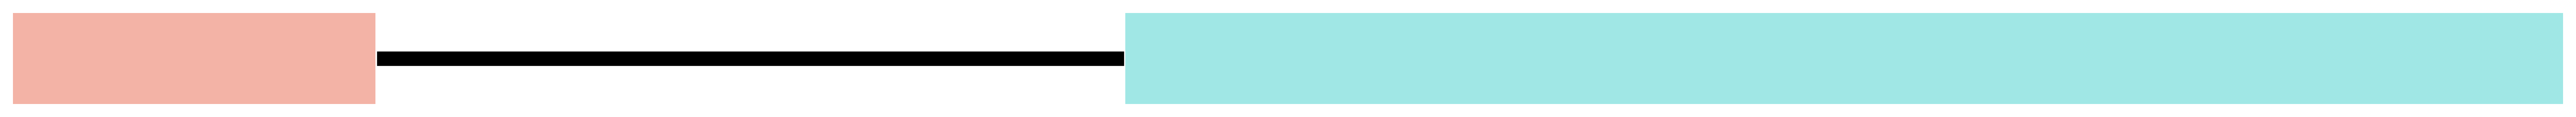

In [87]:
import matplotlib.pyplot as plt

# define box coordinates (x, y, width, height, color)
boxes = [
    (0, 0, 39, 1, '#F3B3A6'),   # 1 -> rectangle
    (40, 0, 77, 1, 'w'),        # 2 -> line
    (118, 0, 328, 1, '#A0E7E5'),# 3 -> rectangle
    (446, 0, 24, 1, '#DACF6D'), # 4 -> line
    (470, 0, 61, 1, '#FBE7C6'), # 5 -> rectangle
    (532, 0, 4, 1, '#61BDD2')   # 6 -> line
]

box_names = ['', '', '', '', '', '']

# create figure and axis for residues 1-269
fig, ax = plt.subplots(figsize=(20, 1))

# add rectangles and lines
for i, (box, name) in enumerate(zip(boxes, box_names), start=1):
    x, y, w, h, color = box
    if i in [1, 3, 5]:
        # draw filled rectangle
        rect = plt.Rectangle((x, y), w, h, color=color)
        ax.add_patch(rect)
    else:
        # draw black horizontal line
        ax.plot([x, x + w], [y + h/2, y + h/2], color='black', linewidth=8)

    # add label if exists
    if name:
        text_x = x + w / 2
        text_y = y + h / 2
        ax.text(text_x, text_y, name, va='center', ha='center',
                color='black', fontsize=48, weight='bold')

# axis styling for first part
ax.set_xlim(1, 269)
ax.set_ylim(0, 1)
ax.axis('off')

plt.tight_layout()
plt.savefig("results/figures/GBA1_domains_part1.pdf", bbox_inches='tight')
plt.show()

## residues from 270 to the end

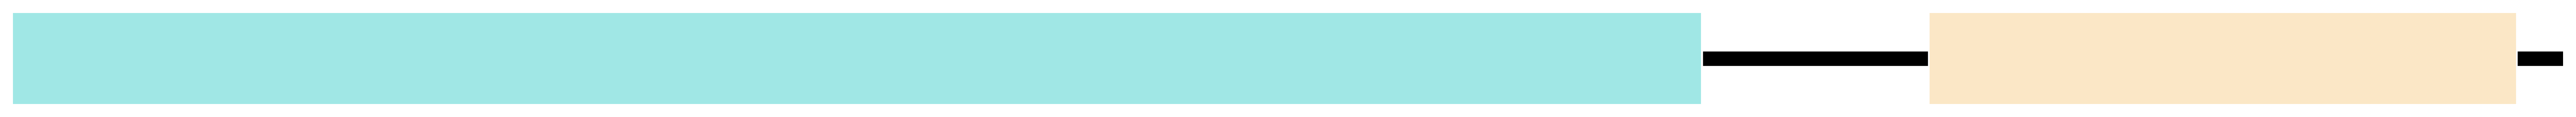

In [88]:
import matplotlib.pyplot as plt

# define box coordinates (x, y, width, height, color)
boxes = [
    (1, 0, 39, 1, '#F3B3A6'),   # 1 -> rectangle
    (40, 0, 78, 1, 'w'),        # 2 -> line
    (118, 0, 328, 1, '#A0E7E5'),# 3 -> rectangle
    (447, 0, 22, 1, '#DACF6D'), # 4 -> line
    (470, 0, 61, 1, '#FBE7C6'), # 5 -> rectangle
    (532, 0, 4, 1, '#61BDD2')   # 6 -> line
]

box_names = ['', '', '', '', '', '']

# create figure and axis for residues 270-end
fig, ax = plt.subplots(figsize=(20, 1))

# add rectangles and lines
for i, (box, name) in enumerate(zip(boxes, box_names), start=1):
    x, y, w, h, color = box
    if i in [1, 3, 5]:
        # draw filled rectangle
        rect = plt.Rectangle((x, y), w, h, color=color)
        ax.add_patch(rect)
    else:
        # draw black horizontal line
        ax.plot([x, x + w], [y + h/2, y + h/2], color='black', linewidth=8)

    # add label if exists
    if name:
        text_x = x + w / 2
        text_y = y + h / 2
        ax.text(text_x, text_y, name, va='center', ha='center',
                color='black', fontsize=48, weight='bold')

# axis styling for second part
ax.set_xlim(270, 536)
ax.set_ylim(0, 1)
ax.axis('off')

plt.tight_layout()
plt.savefig("results/figures/GBA1_domains_part2.pdf", bbox_inches='tight')
plt.show()

# plot median scores across the protein sequence





In [89]:
df = variantsScore_melt[library]

vmin=-0.5
vmax=0.4

fig, ax = plt.subplots(figsize=(80, 2))

# Plot the heatmap (mean score per position)
heatmap_data = df[['position', 'median_score']].pivot_table(index='position', values='median_score')
heatmap_data = heatmap_data.reset_index(drop=True)

# Filter data for positions 0-269
heatmap_data_part1 = heatmap_data.iloc[0:269]

# Create a heatmap with the data
sns.heatmap(heatmap_data_part1.T, cmap='RdBu_r', ax=ax, vmin=vmin, vmax=vmax, cbar=False)

# Remove all ticks and labels
ax.tick_params(top=False, bottom=False, left=False, right=False,
               labeltop=False, labelbottom=False, labelleft=False, labelright=False)

# Remove y-axis label
ax.set_ylabel('')

# Set x-axis limits to show only positions 0-269
ax.set_xlim(0, 270)

# Save the figure to a file
plt.tight_layout()
fig.savefig(f"results/figures/GBA1_meanScore_part1_0-269.pdf", dpi=600)
plt.show()
df = variantsScore_melt[library]

vmin=-0.5
vmax=0.4

fig, ax = plt.subplots(figsize=(80, 2))

# Plot the heatmap (mean score per position)
heatmap_data = df[['position', 'median_score']].pivot_table(index='position', values='median_score')
heatmap_data = heatmap_data.reset_index(drop=True)

# Filter data for positions 270 to end
heatmap_data_part2 = heatmap_data.iloc[269:]

# Create a heatmap with the data
sns.heatmap(heatmap_data_part2.T, cmap='RdBu_r', ax=ax, vmin=vmin, vmax=vmax, cbar=False)

# Remove all ticks and labels
ax.tick_params(top=False, bottom=False, left=False, right=False,
               labeltop=False, labelbottom=False, labelleft=False, labelright=False)

# Remove y-axis label
ax.set_ylabel('')

# Save the figure to a file
plt.tight_layout()
fig.savefig(f"results/figures/GBA1_meanScore_part2_270-end.pdf", dpi=600)
plt.show()

In [90]:
# Step 1: Count barcodes per amino acid substitution
variant_counts = df_bcScore_data.groupby('aa_substitutions').size()

# Step 2: Reference variant scores DataFrame
var_scores = variants_score_dict['gba1_r1']

# Step 3: Loop through all variants and collect results
results = []

for variant in variant_counts.index:
    count = variant_counts[variant]

    try:
        var_fdr = var_scores[var_scores['aa_substitutions'] == variant]['FDR'].values[0]
        score = var_scores[var_scores['aa_substitutions'] == variant]['variant_score'].values[0]
    except IndexError:
        var_fdr = float('nan')
        score = float('nan')

    var_fdr_ther = ''
    if pd.notna(var_fdr) and var_fdr > 0.05:
        var_fdr_ther = "no difference from WT"

    results.append({
        'aa_substitutions': variant,
        'barcode_count': count,
        'FDRvalue': var_fdr,
        'variant_score': score,
        'FDR_interpretation': var_fdr_ther
    })

# Step 4: Save to CSV
results_df = pd.DataFrame(results)
results_df.to_csv("results/scores/GBA1_variants_withBCcount_FDRvalues.csv", index=False)
print("Saved to GBA1_variants_withBCcount_FDRvalues.csv")

Saved to GBA1_variants_withBCcount_FDRvalues.csv


Columns in variants_score_dict['gba1_r1'] DataFrame:
['aa_substitutions', 'variant_score', 'FDR', 'barcode_count', 'confidence', 'wt_aa', 'position', 'variant_aa']


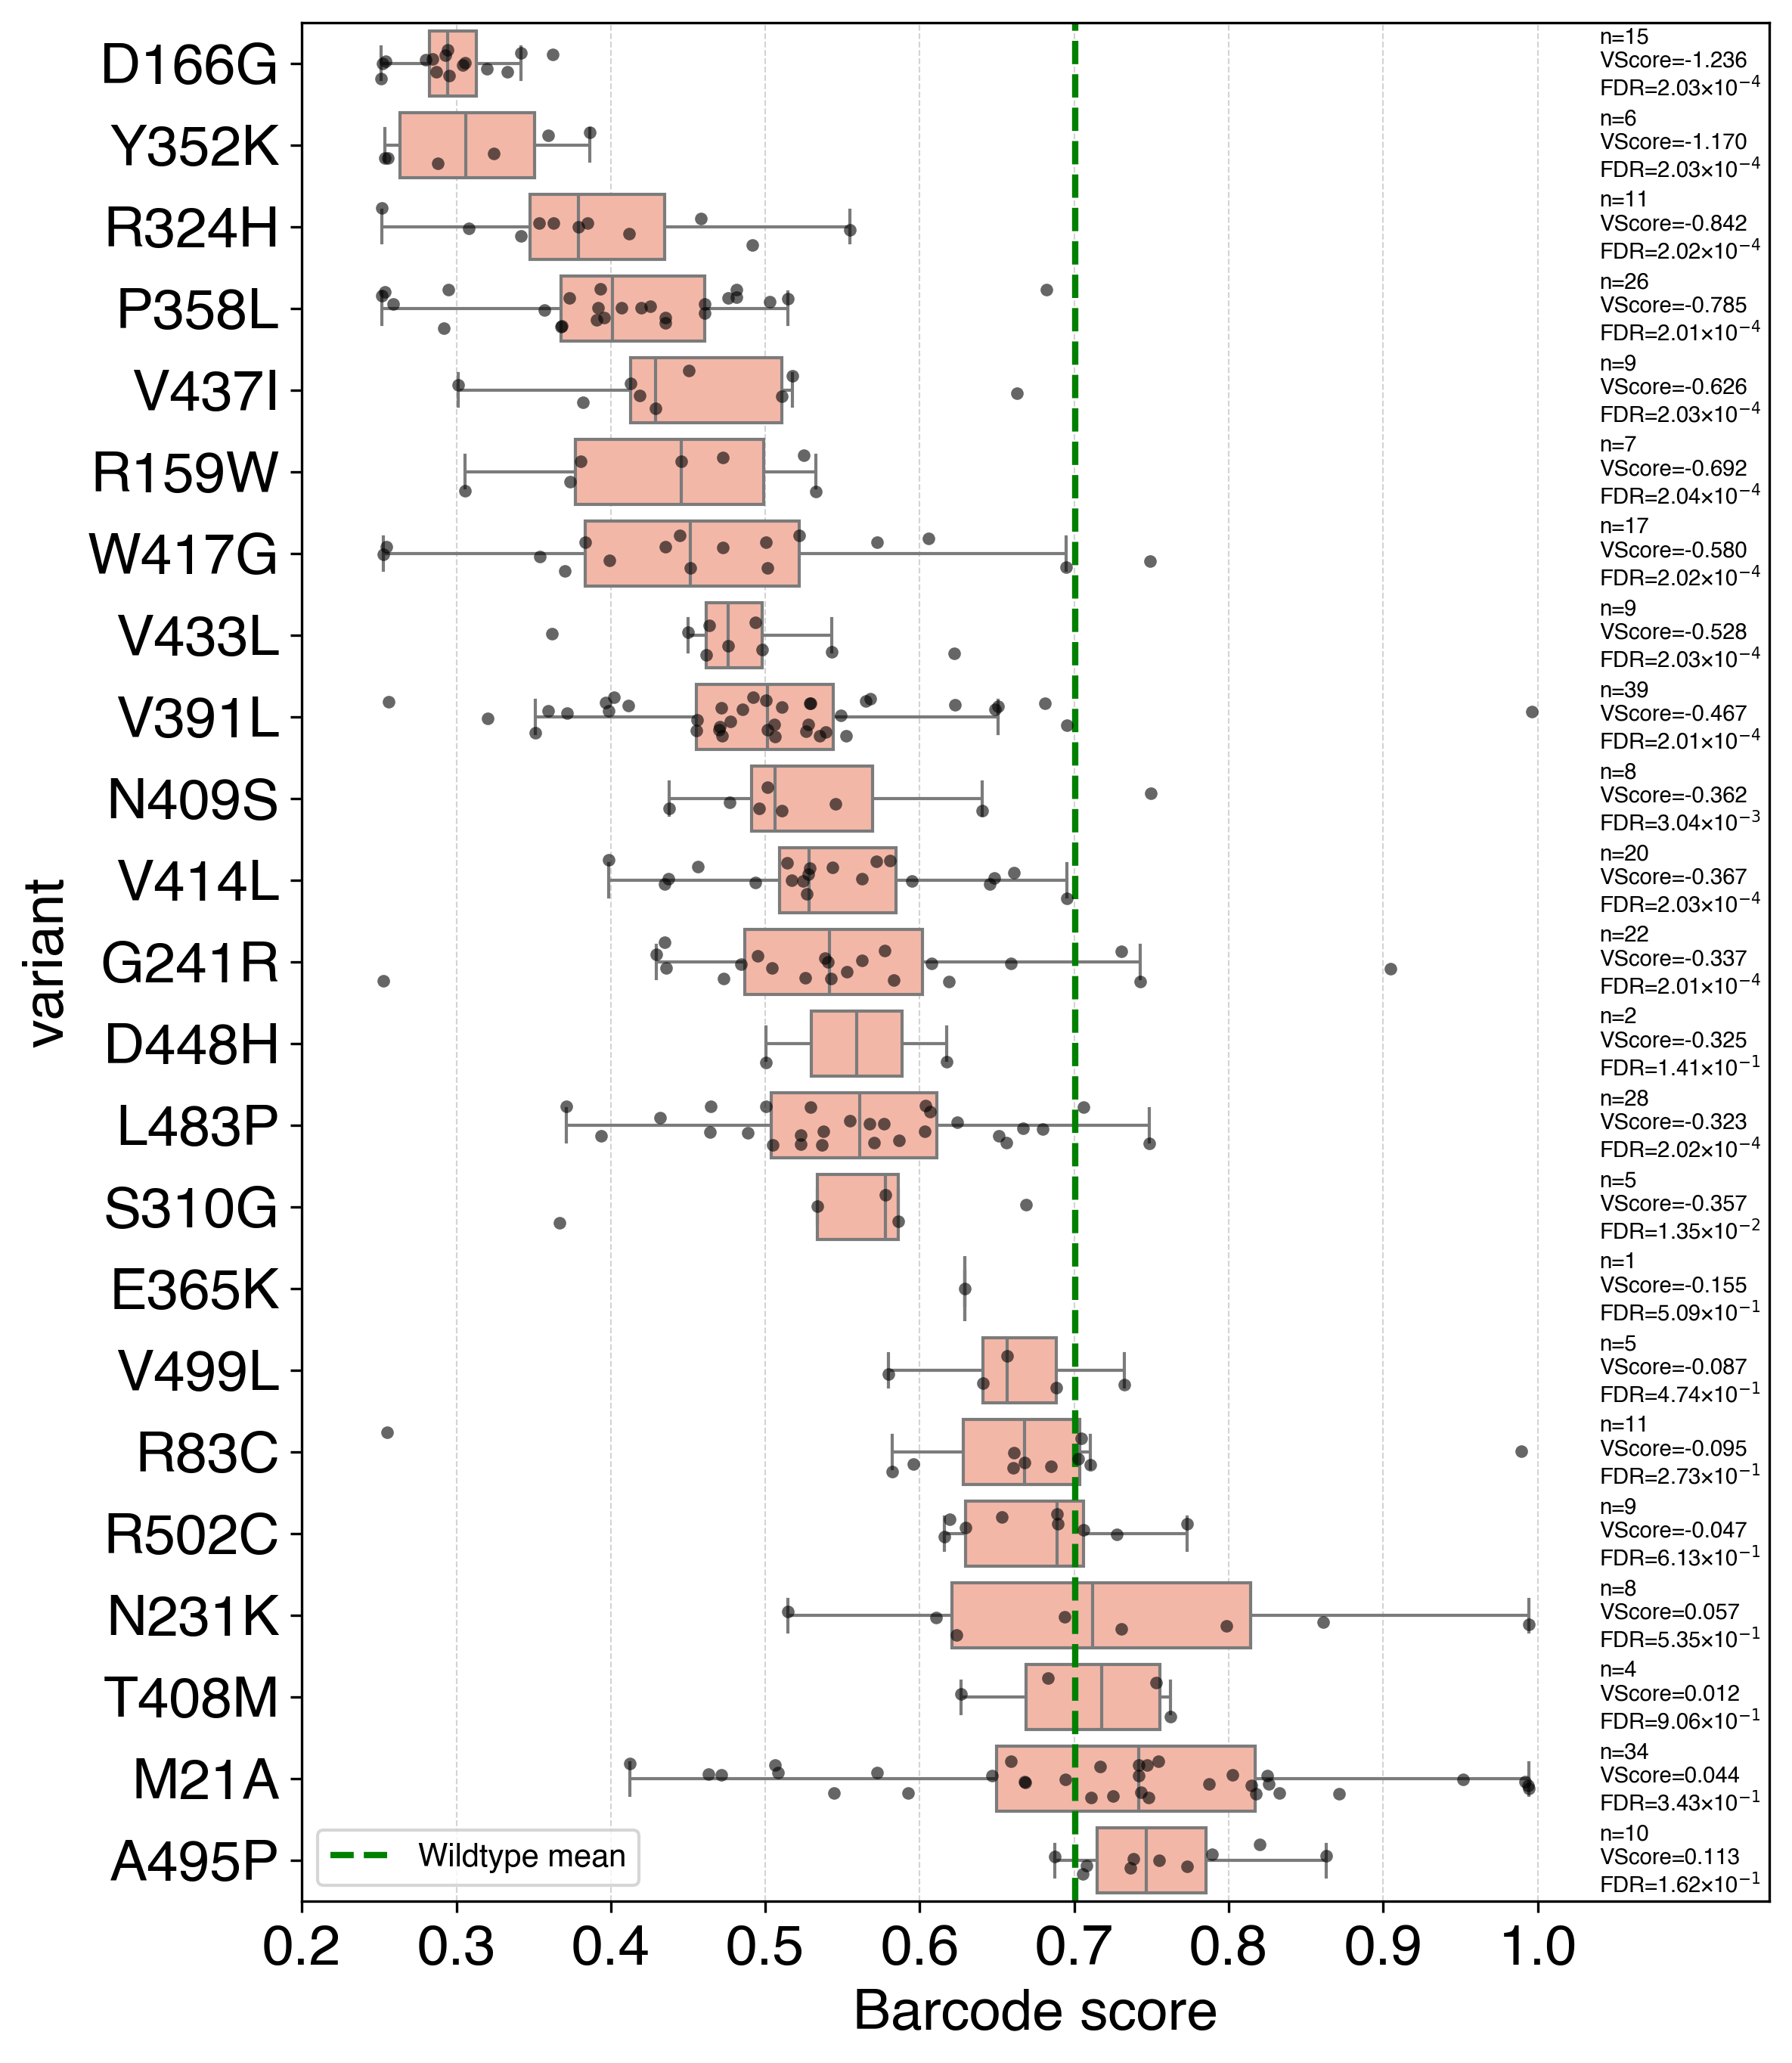

In [92]:
# --- Setup: Selected variants ---
selected_variants = [
    "R159W", "G241R", "V414L", "V433L", "D448H", "L483P", "R502C", "S310G",
    "N409S", "W417G", "V437I", "V499L", "E365K", "R83C", "N231K", "R342H",
    "P358L", "V391L", "T408M", "A495P", "M1A", "M21A", "D166G", "Y352K","R324H"
]


# --- Step 1: Filter data to selected variants ---
bc_score = df_bcScore_data.copy()
sel_vars = bc_score[bc_score['aa_substitutions'].isin(selected_variants)].copy()

# --- Step 2: Order by median score ---
order = (
    sel_vars
    .groupby('aa_substitutions')['gba1_r1 Gcase flowSeq']
    .median()
    .sort_values()
    .index
)

# --- Step 3: Counts per variant ---
counts = sel_vars['aa_substitutions'].value_counts()

# --- Step 4: Pull variant scores and FDR from variants_score_dict['gba1_r1'] ---
print("Columns in variants_score_dict['gba1_r1'] DataFrame:")
print(variants_score_dict['gba1_r1'].columns.tolist())

var_scores_df = variants_score_dict['gba1_r1']
variant_info = var_scores_df[var_scores_df['aa_substitutions'].isin(selected_variants)]

variant_scores = dict(zip(variant_info['aa_substitutions'], variant_info['variant_score']))  # confirm this column name
fdr_values = dict(zip(variant_info['aa_substitutions'], variant_info['FDR']))  # matches your working code1

for aa in order:
    if aa not in variant_scores:
        print(f"Warning: {aa} not found in variants_score_dict['gba1_r1'] DataFrame")
        variant_scores[aa] = np.nan
    if aa not in fdr_values:
        fdr_values[aa] = np.nan

# --- Step 5: Plot ---
plt.figure(figsize=(8, max(5, len(order) * 0.4)))

ax = sns.boxplot(
    data=sel_vars,
    y='aa_substitutions',
    x='gba1_r1 Gcase flowSeq',
    order=order,
    showfliers=False,
    color='#ffb09c'
)

sns.stripplot(
    data=sel_vars,
    y='aa_substitutions',
    x='gba1_r1 Gcase flowSeq',
    order=order,
    color='black',
    size=4,
    jitter=0.25,
    alpha=0.6
)

def format_fdr_scientific(fdr_value):
    """Format FDR value in scientific notation like 2.03×10^-3"""
    if pd.isna(fdr_value):
        return "N/A"
    elif fdr_value == 0:
        return "0"
    else:
        sci_str = f"{fdr_value:.2e}"
        coeff, exp = sci_str.split('e')
        coeff = float(coeff)
        exp = int(exp)
        return f"{coeff:.2f}×10$^{{{exp}}}$"

for i, aa in enumerate(order):
    n = counts[aa]
    vs = variant_scores.get(aa, np.nan)
    fdr = fdr_values.get(aa, np.nan)

    if pd.isna(vs) or pd.isna(fdr):
        annotation = f'n={n}\nVscore=N/A\nFDR=N/A'
    else:
        fdr_formatted = format_fdr_scientific(fdr)
        annotation = f'n={n}\nVScore={vs:.3f}\nFDR={fdr_formatted}'

    ax.text(
        x=1.04,
        y=i,
        s=annotation,
        va='center',
        ha='left',
        fontsize=7,
        linespacing=1.2
    )

plt.axvline(
    x=bc_score[bc_score['variant_class'] == 'wildtype']['gba1_r1 Gcase flowSeq'].mean(),
    color='green',
    linestyle='--',
    linewidth=2,
    label='Wildtype mean'
)

plt.legend(loc='lower left')
plt.xlim(0.22, 1.15)  # check this fits your gba1_r1 score range4,

plt.grid(True, color='lightgrey', linewidth=0.5, linestyle='--', axis='x')

plt.xlabel('Barcode score', fontsize=18)
plt.ylabel('variant', fontsize=18)
plt.xticks(np.arange(0.2, 1.01, 0.1), size=18)
plt.xticks(size=18)
plt.yticks(size=18)

plt.tight_layout()
plt.savefig('results/figures/selected_vars_boxplot_gba1_r1.pdf')
plt.show()

sel_vars_export = sel_vars[['barcode', 'codon_substitutions', 'aa_substitutions', 'gba1_r1 Gcase flowSeq']]
sel_vars_export.to_csv('results/FigS_selected_variants.csv', index=False)

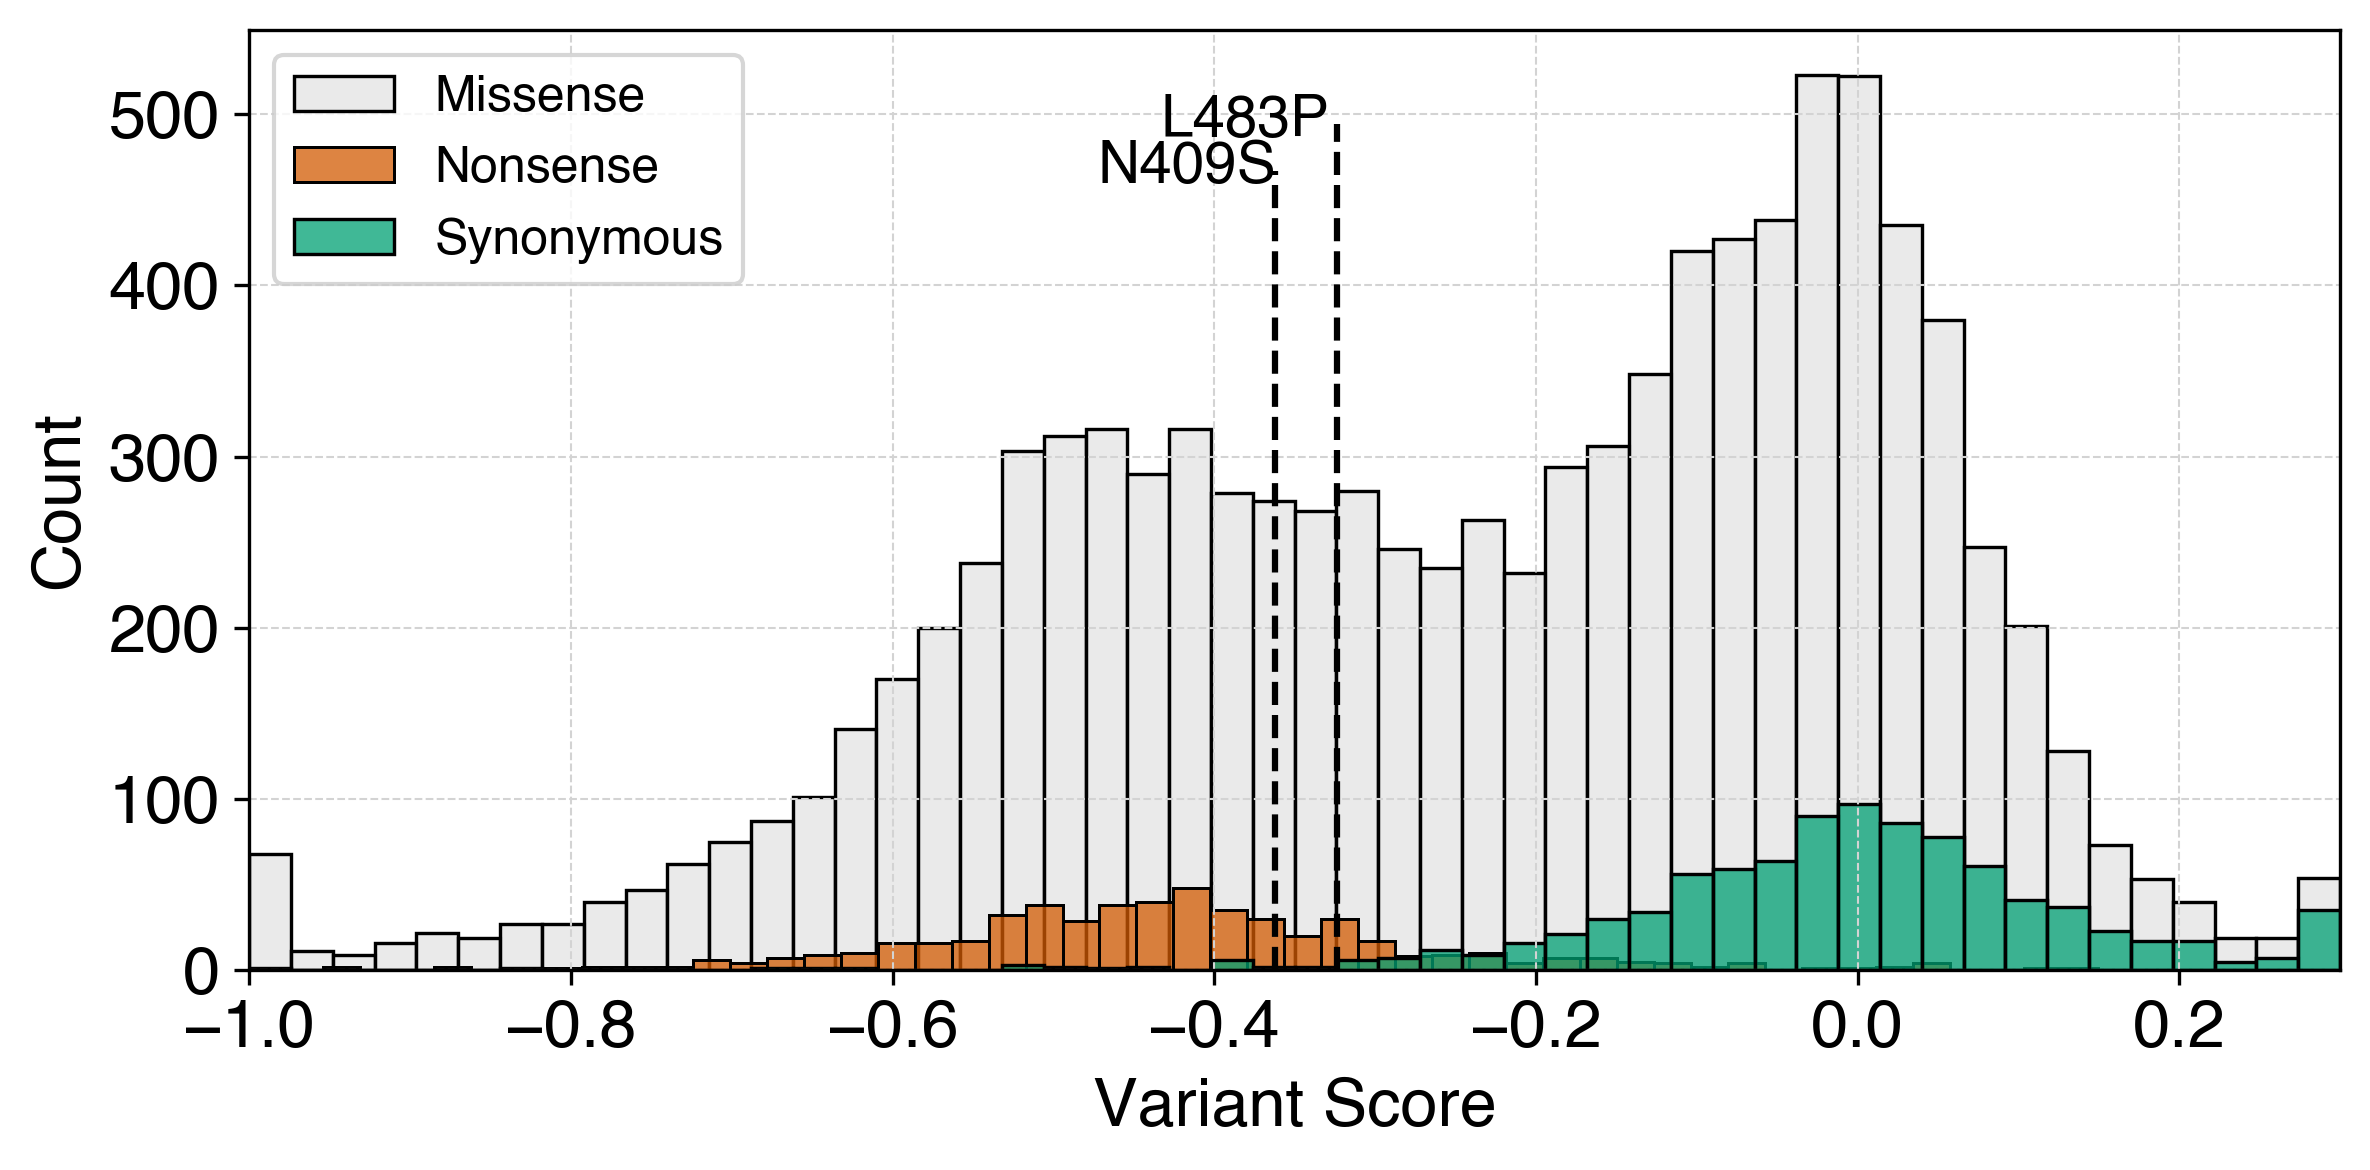

In [93]:
df_plot=variants_score_dict['gba1_r1'].copy()

# Filter selected variants (make sure formatting matches your df)
variants_of_interest = ['N409S','L483P']  # <-- remove "p." if not in df
selected_variants = df_plot[df_plot['aa_substitutions'].isin(variants_of_interest)].copy()
selected_variants.rename(columns={'gba1_r1': 'variant_score'}, inplace=True)

plt.figure(figsize=(8,4))

# Clip variant scores correctly
df_plot_clipped = df_plot.copy()
df_plot_clipped['variant_score'] = df_plot_clipped['variant_score'].clip(lower=-1, upper=0.3)

syn_score_clipped = syn_score.copy()
syn_score_clipped['variant_score'] = syn_score_clipped['gba1_r1'].clip(lower=-1, upper=0.3)

# Histograms
sns.histplot(df_plot_clipped.loc[~df_plot_clipped['aa_substitutions'].str.endswith('*'), 'variant_score'],
             bins=50, color='#e4e4e4', label='Missense', alpha=0.75)

sns.histplot(df_plot_clipped.loc[df_plot_clipped['aa_substitutions'].str.endswith('*'), 'variant_score'],
             bins=50, color='#d25b03', label='Nonsense', alpha=0.75)

sns.histplot(syn_score_clipped['variant_score'], bins=50, color='#00a073',
             label='Synonymous', alpha=0.75)

# Overlay vertical lines for specific variants
y_max = plt.ylim()[1]
y_positions = [0.9, 0.85, 0.8, 0.75]

for i, (_, row) in enumerate(selected_variants.iterrows()):
    x_score = max(row['variant_score'], -1)  
    plt.vlines(x=x_score, ymin=0, ymax=y_positions[i]*y_max, 
               color='black', linestyle='--', linewidth=1.5)
    plt.text(x_score - 0.11, y_positions[i]*y_max*0.97,  
             row['aa_substitutions'], va='bottom', ha='left', fontsize=14)

plt.xlabel('Variant Score', fontsize=16)
plt.ylabel('Count', fontsize=16)
plt.xticks(size=16)
plt.yticks(size=16)
plt.legend(fontsize=12)
plt.grid(True, color='lightgrey', linewidth=0.5, linestyle='--')
plt.xlim(-1, 0.3)
plt.savefig('results/figures/variant_score_distribution.pdf', bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()